# Bin-sweep OP-map reconstruction — percentile grids & control distributions

Reads `errors_long_binsweep.pkl` (from `compute_binsweep.py`) and visualises the
uniform-random control analysis with the **improved min-over-pairs test**.

For each (monkey, date, array, condition, bin_ms):
- **real statistic** = min over PC pairs of the real error (best reconstruction)
- **null** = for each control map, min over PC pairs of its error
- **percentile** = `100 * mean(null_min <= real_min)` — low = beats control

Everything is shown for both **L1** and **L2** norms. Pick the FR bin size with
`BIN_MS` below.

## Imports, parameters & data

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

with open("params_binsweep.yml") as f:
    P = yaml.safe_load(f)

DF_FOLDER  = P["df_folder"]
MONKEYS    = P["monkeys"]
V1_ARRAYS  = P["v1_arrays"]
DATES      = P["dates"]
BIN_SIZES  = P["method"]["bin_sizes"]
COLORS_M   = P["colors_monkeys"]

plt.rcParams["figure.facecolor"] = "white"

df = pd.read_pickle(os.path.join(DF_FOLDER, "errors_long_binsweep.pkl"))
print("rows:", len(df))
print("bins:", sorted(df["bin_ms"].unique()))
print("conditions:", df["condition"].unique(), "| norms:", df["norm"].unique())
print("sources:", df["source"].unique())
df.head()

rows: 124214076
bins: [np.int64(20), np.int64(50), np.int64(100), np.int64(250), np.int64(500), np.int64(750), np.int64(1000)]
conditions: ['all' 'EC' 'EO'] | norms: ['L1' 'L2']
sources: ['real' 'ctrl']


,monkey,date,array,condition,bin_ms,pc_pair,pc_x,pc_y,source,ctrl_idx,norm,error
0,F,20240122_B1,1,all,100,PC1 vs PC2,1,2,real,-1,L1,34.265514
1,F,20240122_B1,1,all,100,PC1 vs PC2,1,2,real,-1,L2,44.383279
2,F,20240122_B1,1,all,100,PC1 vs PC3,1,3,real,-1,L1,34.892724
3,F,20240122_B1,1,all,100,PC1 vs PC3,1,3,real,-1,L2,45.856276
4,F,20240122_B1,1,all,100,PC1 vs PC4,1,4,real,-1,L1,36.032642


## Choose the FR bin size
All grid / box / histogram plots below use this bin unless they explicitly
sweep over bins.

In [2]:
BIN_MS = 50      # one of BIN_SIZES
assert BIN_MS in BIN_SIZES, f"choose one of {BIN_SIZES}"
dfb = df[df.bin_ms == BIN_MS]
print(f"using bin = {BIN_MS} ms  ({len(dfb)} rows)")

using bin = 50 ms  (17744868 rows)


## Min-over-pairs percentile table (the improved test)

One row per (monkey, date, array, condition, bin_ms, norm): the real best-of-pairs
error, the percentile within the control best-of-pairs null, and null summary stats.

In [3]:
def minpair_percentile_df(d):
    keys = ["monkey", "date", "array", "condition", "bin_ms", "norm"]

    real = d[d.source == "real"]
    real_min = real.groupby(keys)["error"].min().rename("real_error").reset_index()
    ix = real.groupby(keys)["error"].idxmin()
    rp = real.loc[ix, keys + ["pc_pair", "pc_x", "pc_y"]].reset_index(drop=True)
    real_min = real_min.merge(rp, on=keys, how="left")

    ctrl = d[d.source == "ctrl"]
    ctrl_min = (ctrl.groupby(keys + ["ctrl_idx"])["error"].min()
                .rename("ctrl_min").reset_index())
    na = (ctrl_min.groupby(keys)["ctrl_min"].apply(lambda s: s.to_numpy())
          .rename("null_vals").reset_index())

    merged = real_min.merge(na, on=keys, how="left")

    def _stats(row):
        nv = row["null_vals"]; re = row["real_error"]
        if isinstance(nv, np.ndarray) and len(nv) and not np.isnan(re):
            return pd.Series({
                "percentile": 100.0 * np.mean(nv <= re),
                "null_mean": float(np.mean(nv)),
                "null_p05": float(np.percentile(nv, 5)),
                "null_p95": float(np.percentile(nv, 95)),
                "n_ctrl": len(nv)})
        return pd.Series({"percentile": np.nan, "null_mean": np.nan,
                          "null_p05": np.nan, "null_p95": np.nan, "n_ctrl": 0})

    stats = merged.apply(_stats, axis=1)
    out = pd.concat([merged.drop(columns=["null_vals"]), stats], axis=1)
    out["array"] = out["array"].astype(int)
    out["n_ctrl"] = out["n_ctrl"].astype(int)
    return out

mp = minpair_percentile_df(dfb)
print("percentile rows:", len(mp), "| controls per cell:", mp["n_ctrl"].unique())
mp.head()

percentile rows: 432 | controls per cell: [2000]


,monkey,date,array,condition,bin_ms,norm,real_error,pc_pair,pc_x,pc_y,percentile,null_mean,null_p05,null_p95,n_ctrl
0,F,20240122_B1,1,EC,50,L1,28.450860,PC2 vs PC3,2,3,70.05,26.720202,21.107733,31.498676,2000
1,F,20240122_B1,1,EC,50,L2,36.072390,PC2 vs PC3,2,3,68.45,34.176494,27.652077,39.413063,2000
2,F,20240122_B1,1,EO,50,L1,29.559039,PC4 vs PC5,4,5,81.20,26.688117,20.922499,31.670890,2000
3,F,20240122_B1,1,EO,50,L2,35.850701,PC4 vs PC6,4,6,66.45,34.181377,27.609046,39.889218,2000
4,F,20240122_B1,1,all,50,L1,28.370810,PC2 vs PC4,2,4,69.55,26.650830,20.958972,31.437791,2000


## Percentile grids — per monkey, L1 vs L2

Rows = arrays, cols = conditions. Colour = percentile of the real best-pair error
in the control null (diverging `bwr` centred on 5%: blue < 5% beats control).
Percentiles are averaged across recording days. Left block = L1, right = L2.

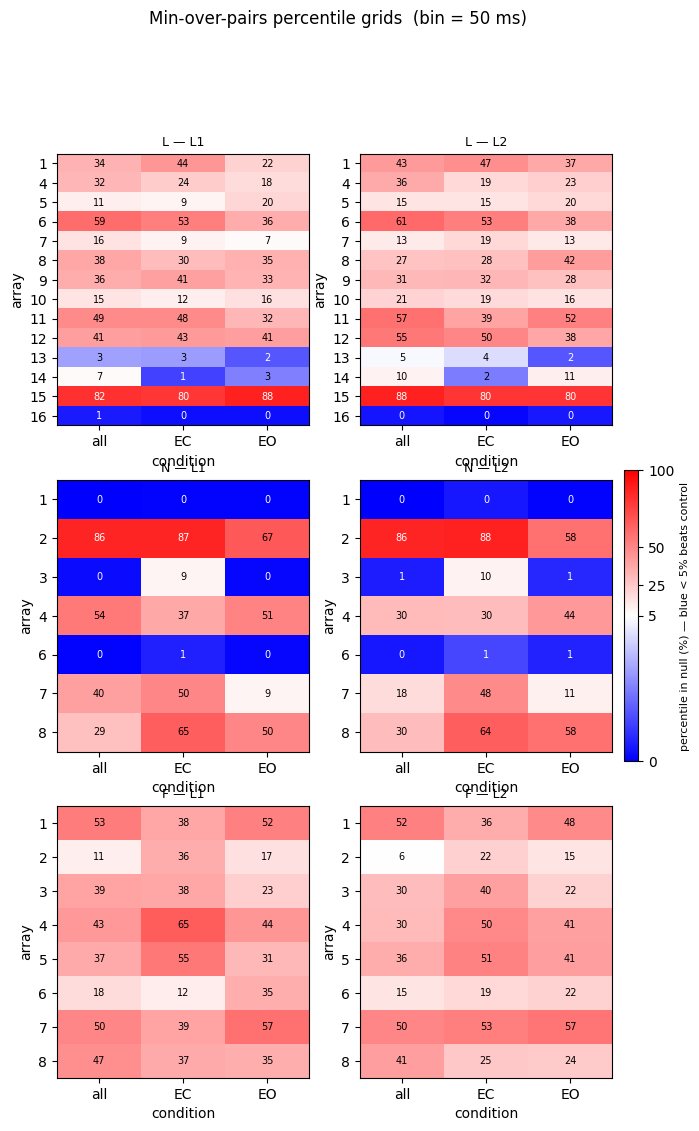

In [4]:
def grid_for(mp, monkey, norm):
    sub = mp[(mp.norm == norm) & (mp.monkey == monkey)]
    conds = [c for c in ["all", "EC", "EO"] if c in sub["condition"].unique()]
    arrays = sorted(sub["array"].unique())
    grid = np.full((len(arrays), len(conds)), np.nan)
    for i, arr in enumerate(arrays):
        for j, cond in enumerate(conds):
            v = sub[(sub.array == arr) & (sub.condition == cond)]["percentile"]
            if len(v):
                grid[i, j] = v.mean()        # average across days
    return arrays, conds, grid

def draw_grid(ax, monkey, norm):
    arrays, conds, grid = grid_for(mp, monkey, norm)
    cnorm = TwoSlopeNorm(vmin=0, vcenter=5, vmax=100)
    im = ax.imshow(grid, cmap="bwr", norm=cnorm, aspect="auto")
    ax.set_xticks(range(len(conds))); ax.set_xticklabels(conds)
    ax.set_yticks(range(len(arrays))); ax.set_yticklabels(arrays)
    ax.set_xlabel("condition"); ax.set_ylabel("array")
    ax.set_title(f"{monkey} — {norm}", fontsize=9)
    for i in range(len(arrays)):
        for j in range(len(conds)):
            v = grid[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7,
                        color="white" if (v < 2 or v > 70) else "black")
    return im

fig, axes = plt.subplots(len(MONKEYS), 2,
                         figsize=(7.5, 4.0*len(MONKEYS)), squeeze=False)
im_last = None
for r, monkey in enumerate(MONKEYS):
    im_last = draw_grid(axes[r][0], monkey, "L1")
    im_last = draw_grid(axes[r][1], monkey, "L2")
cbar = fig.colorbar(im_last, ax=axes, fraction=0.025, pad=0.02,
                    ticks=[0, 5, 25, 50, 100])
cbar.set_label("percentile in null (%) — blue < 5% beats control", fontsize=8)
fig.suptitle(f"Min-over-pairs percentile grids  (bin = {BIN_MS} ms)",
             fontsize=12, y=1.0)
plt.show()

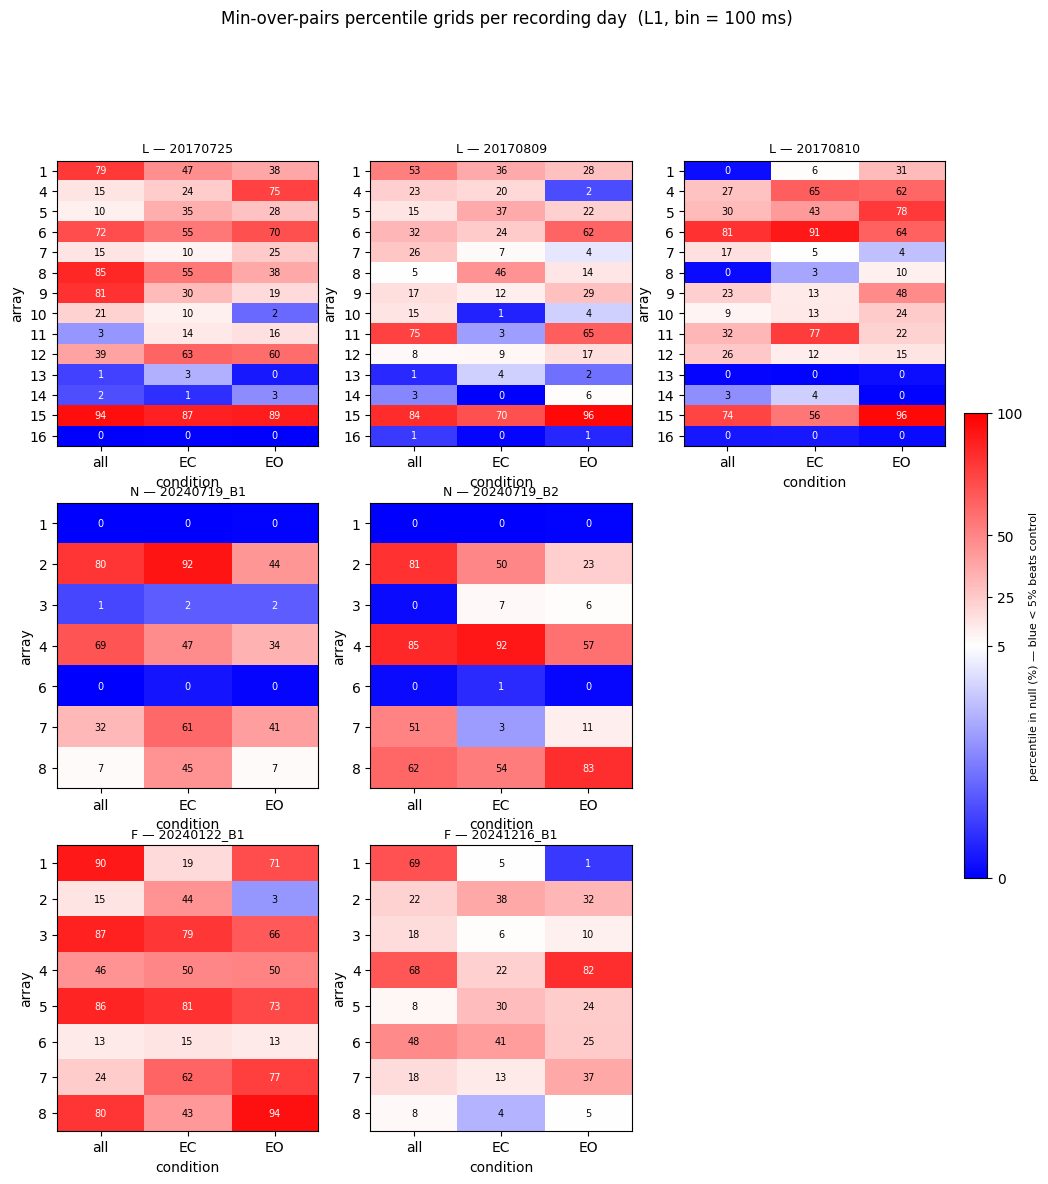

In [14]:
BIN_PLOT = 100
NORM = "L1"

mp100 = minpair_percentile_df(df[df.bin_ms == BIN_PLOT])

def grid_for_day(mp, monkey, date, norm):
    sub = mp[(mp.norm == norm) & (mp.monkey == monkey) & (mp.date == str(date))]
    conds = [c for c in ["all", "EC", "EO"] if c in sub["condition"].unique()]
    arrays = sorted(sub["array"].unique())
    grid = np.full((len(arrays), len(conds)), np.nan)
    for i, arr in enumerate(arrays):
        for j, cond in enumerate(conds):
            v = sub[(sub.array == arr) & (sub.condition == cond)]["percentile"]
            if len(v):
                grid[i, j] = v.iloc[0]      # one value per day (no averaging)
    return arrays, conds, grid

def draw_grid_day(ax, monkey, date, norm):
    arrays, conds, grid = grid_for_day(mp100, monkey, date, norm)
    cnorm = TwoSlopeNorm(vmin=0, vcenter=5, vmax=100)
    im = ax.imshow(grid, cmap="bwr", norm=cnorm, aspect="auto")
    ax.set_xticks(range(len(conds))); ax.set_xticklabels(conds)
    ax.set_yticks(range(len(arrays))); ax.set_yticklabels(arrays)
    ax.set_xlabel("condition"); ax.set_ylabel("array")
    ax.set_title(f"{monkey} — {date}", fontsize=9)
    for i in range(len(arrays)):
        for j in range(len(conds)):
            v = grid[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7,
                        color="white" if (v < 2 or v > 70) else "black")
    return im

monkey_dates = {m: DATES[m]["RS"] for m in MONKEYS}
max_cols = max(len(v) for v in monkey_dates.values())   # 3 (L has the most)

fig, axes = plt.subplots(len(MONKEYS), max_cols,
                         figsize=(4.0*max_cols, 4.2*len(MONKEYS)),
                         squeeze=False)

im_last = None
for r, monkey in enumerate(MONKEYS):
    dates = monkey_dates[monkey]
    for c in range(max_cols):
        ax = axes[r][c]
        if c < len(dates):
            im_last = draw_grid_day(ax, monkey, dates[c], NORM)
        else:
            ax.axis("off")     # blank trailing slot (N, F have only 2 days)

cbar = fig.colorbar(im_last, ax=axes, fraction=0.025, pad=0.02,
                    ticks=[0, 5, 25, 50, 100])
cbar.set_label("percentile in null (%) — blue < 5% beats control", fontsize=8)
fig.suptitle(f"Min-over-pairs percentile grids per recording day  "
             f"({NORM}, bin = {BIN_PLOT} ms)", fontsize=12, y=1.0)
plt.show()

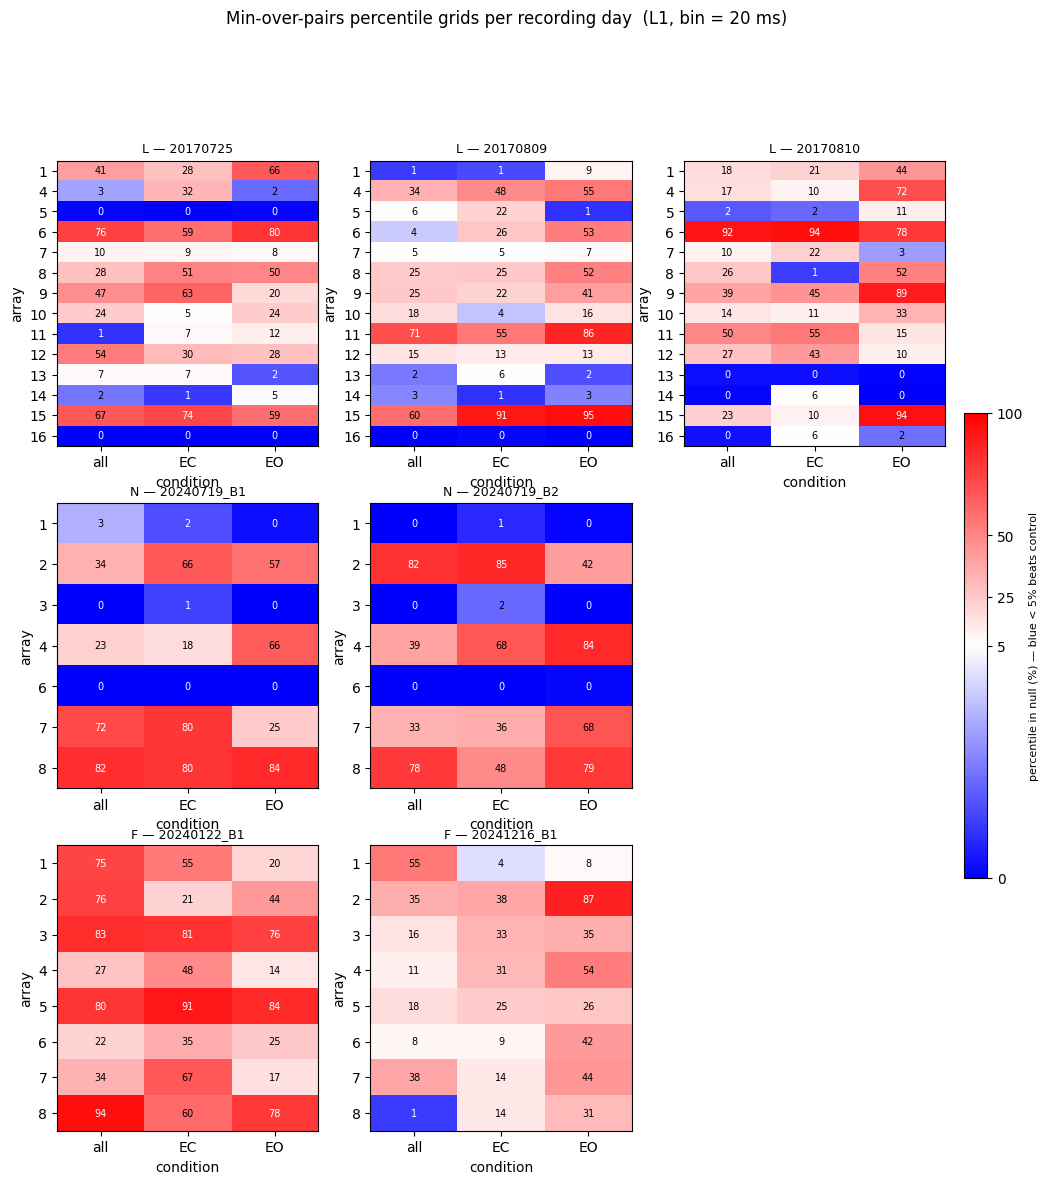

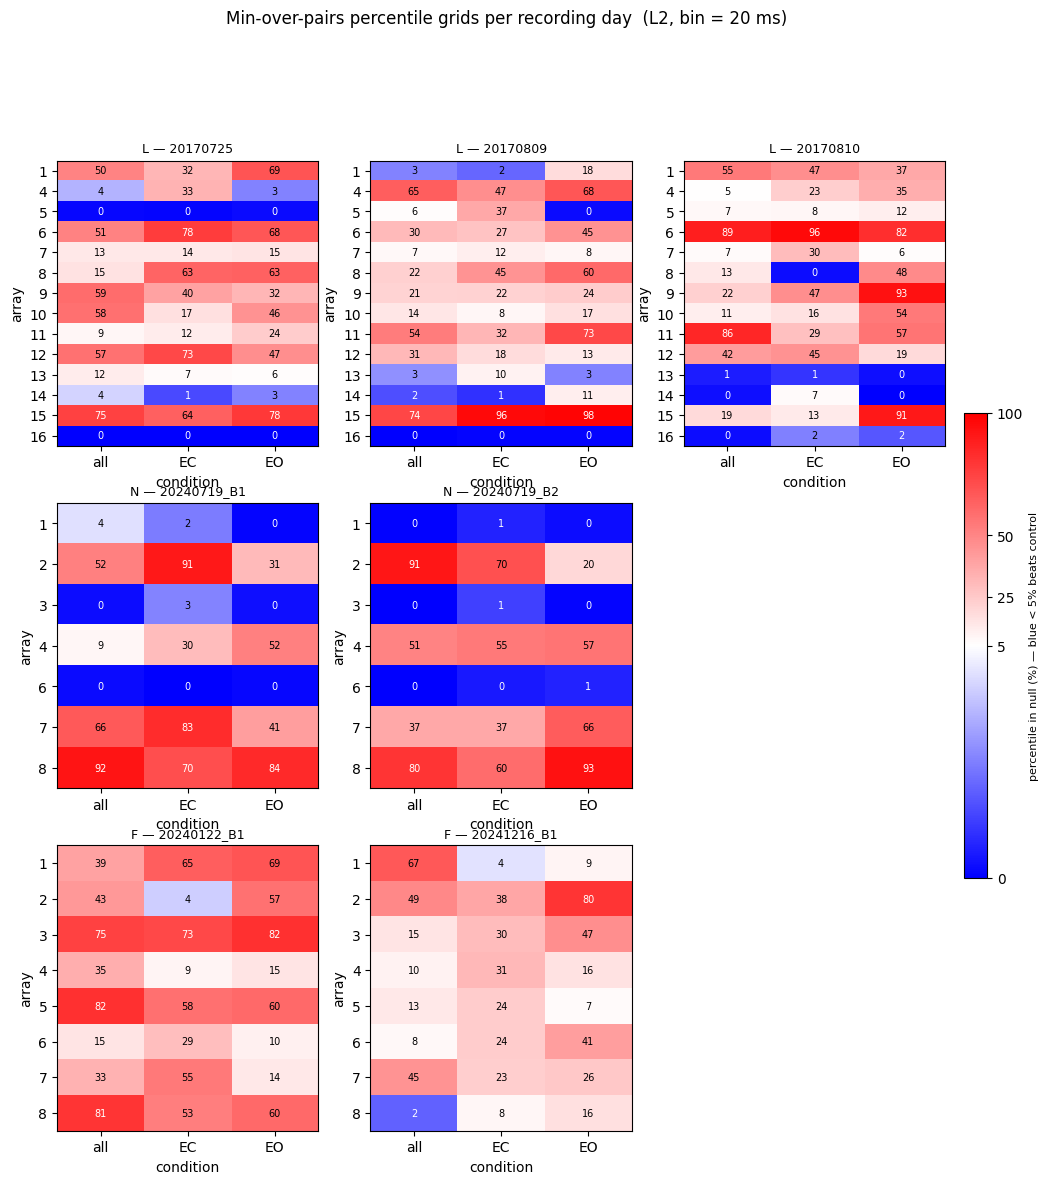

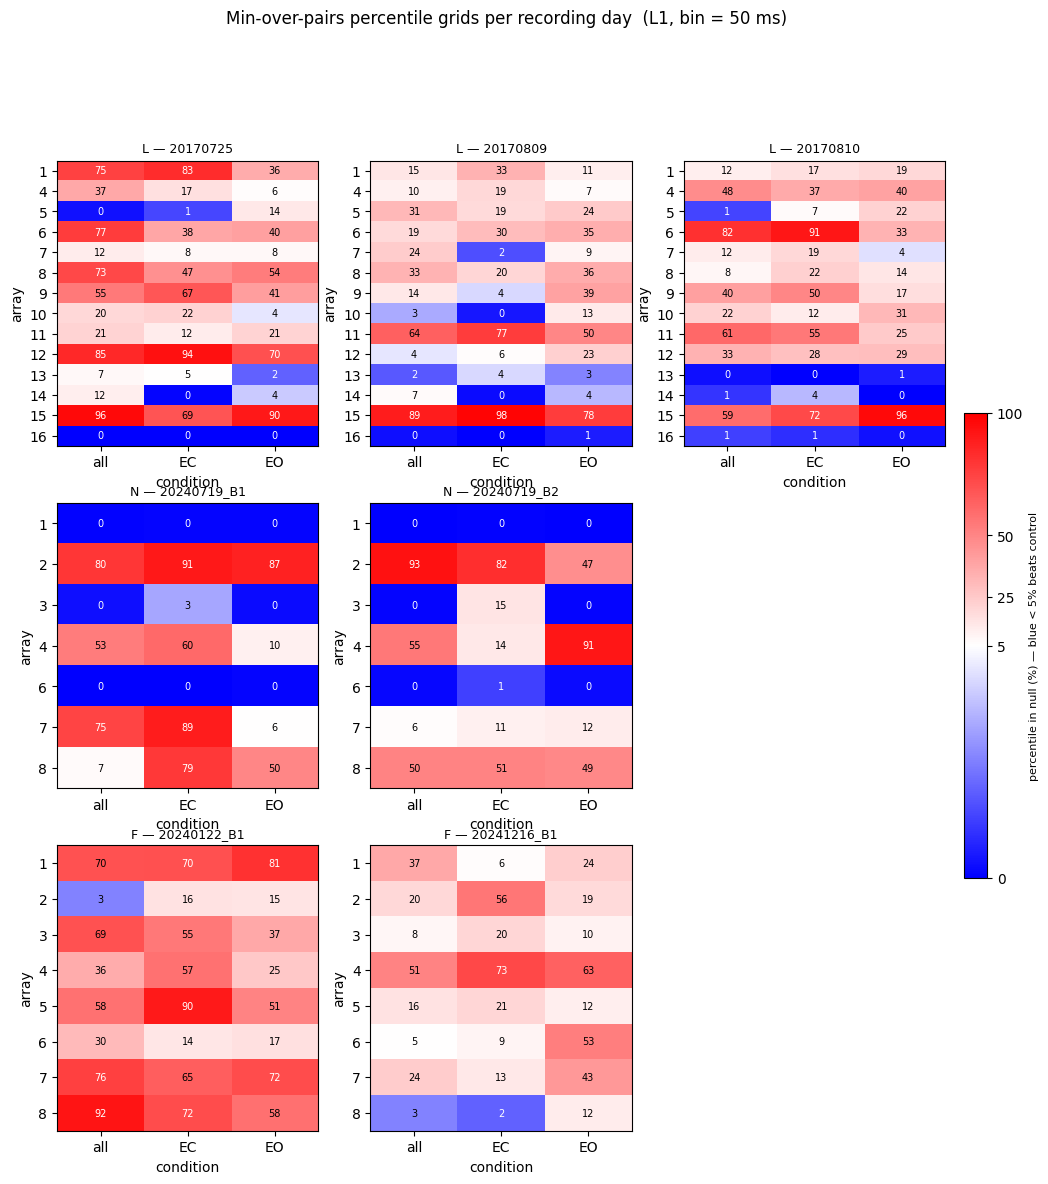

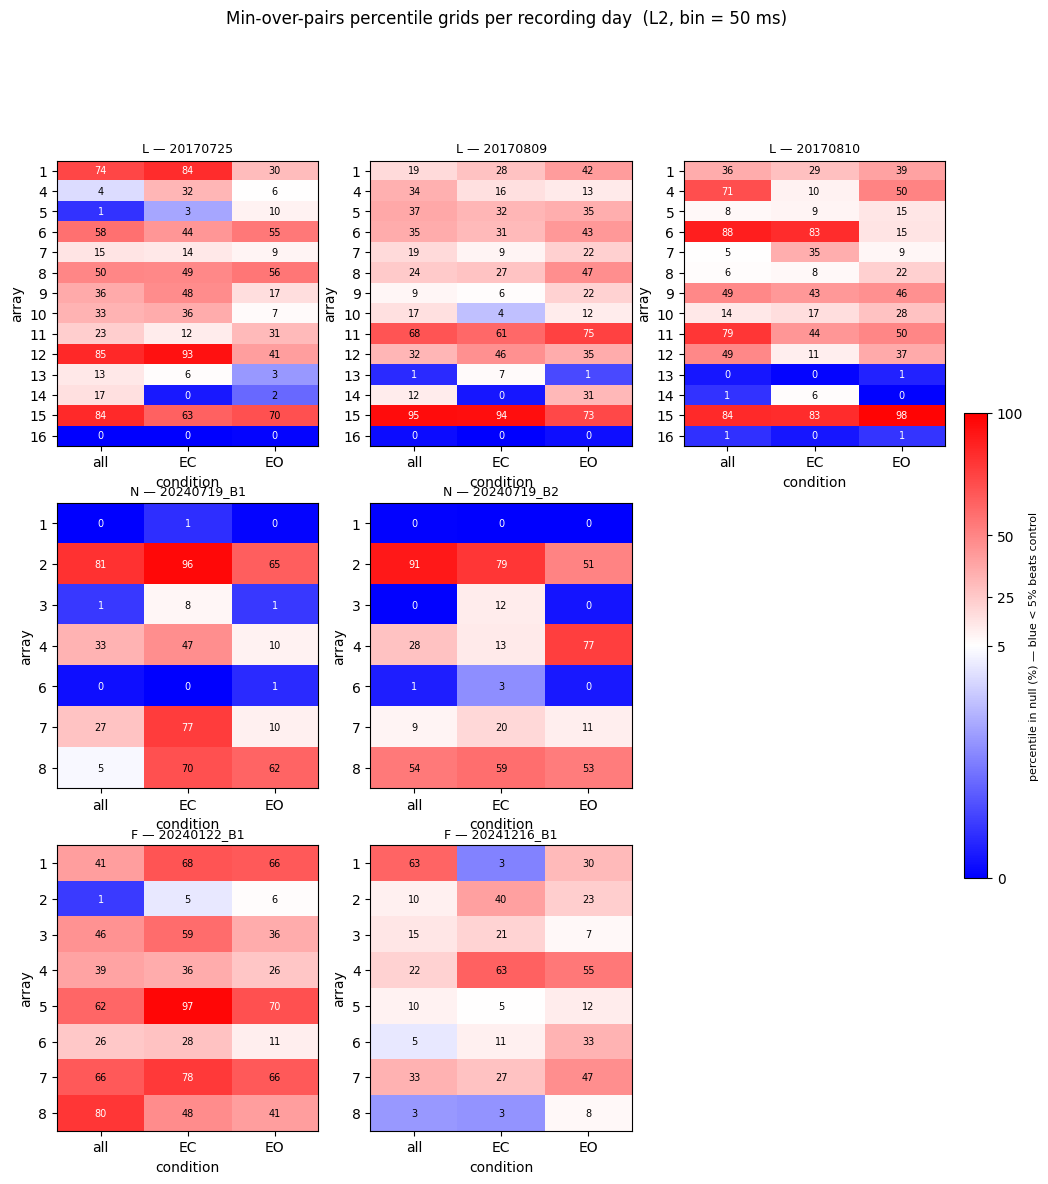

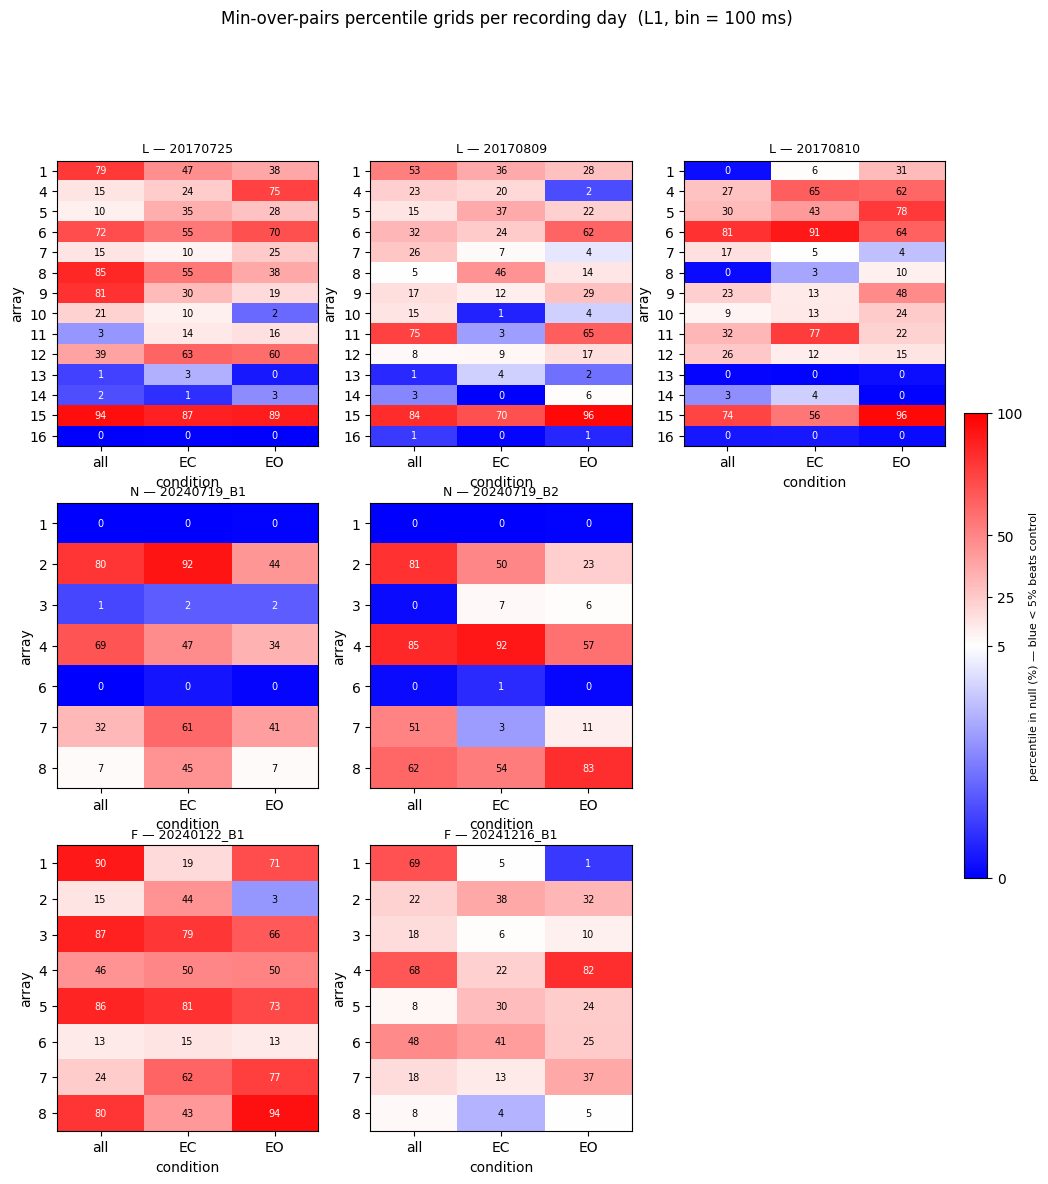

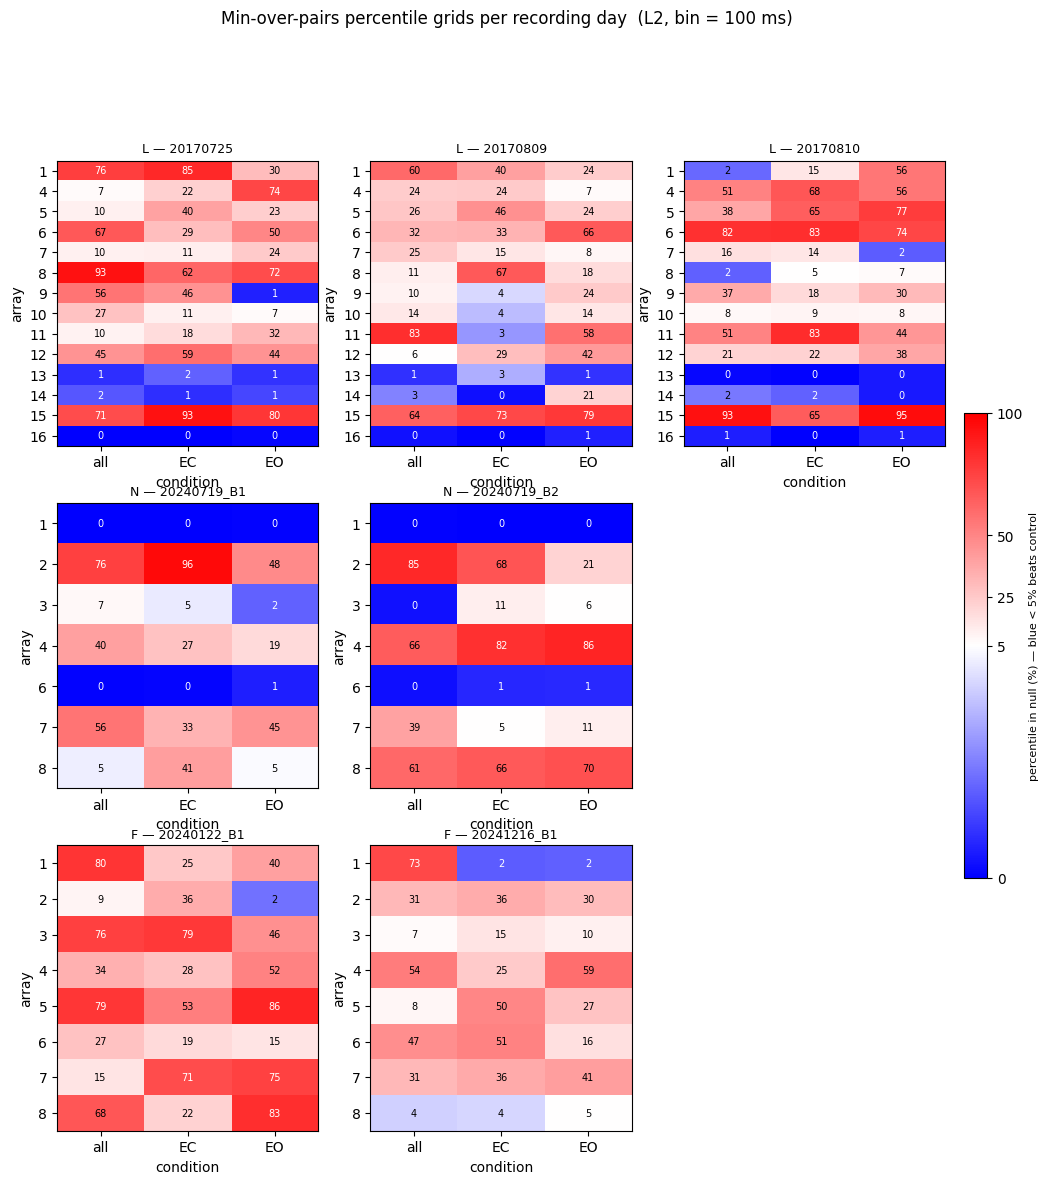

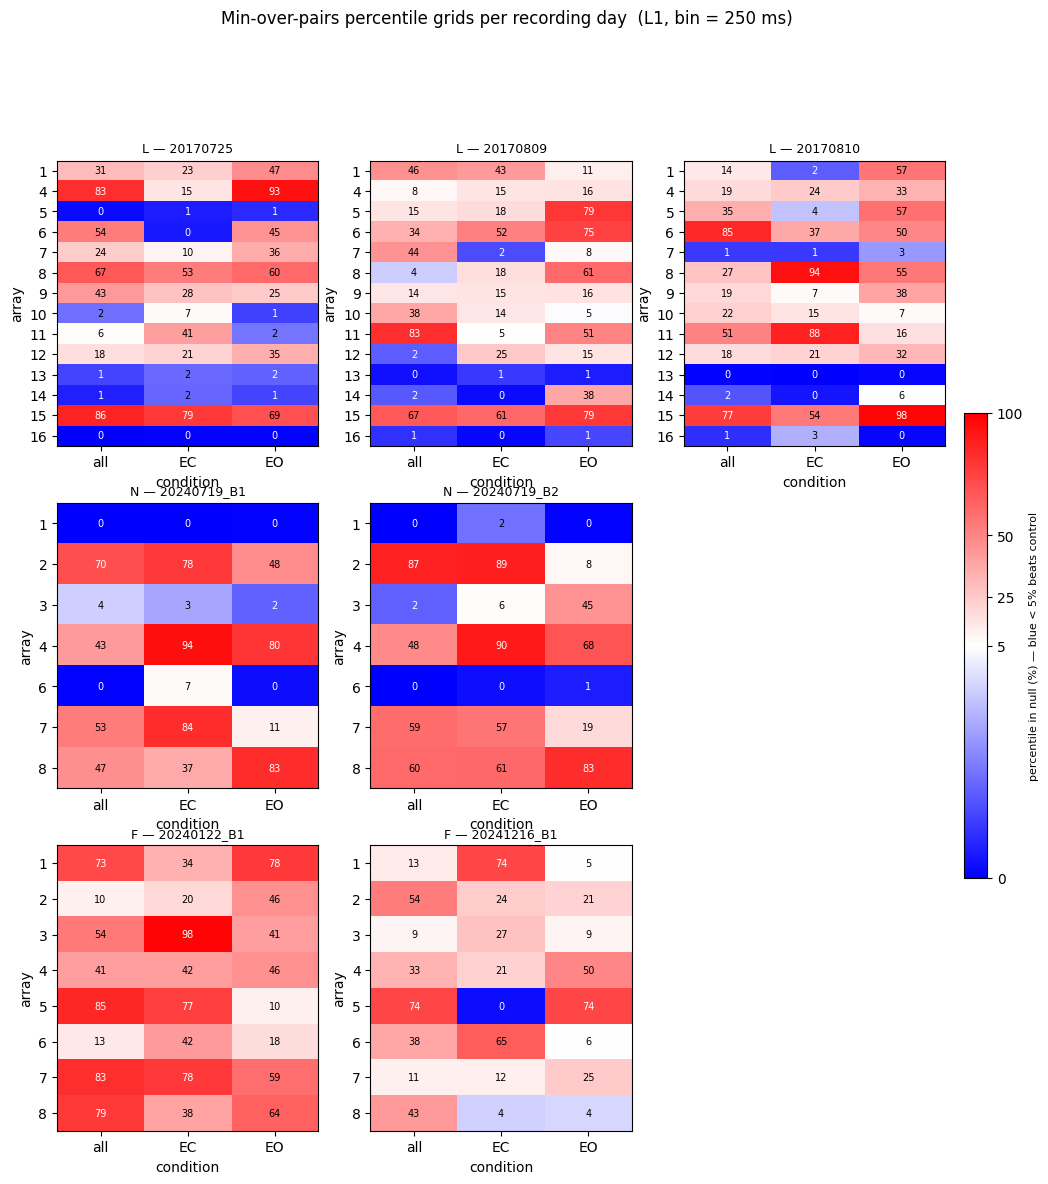

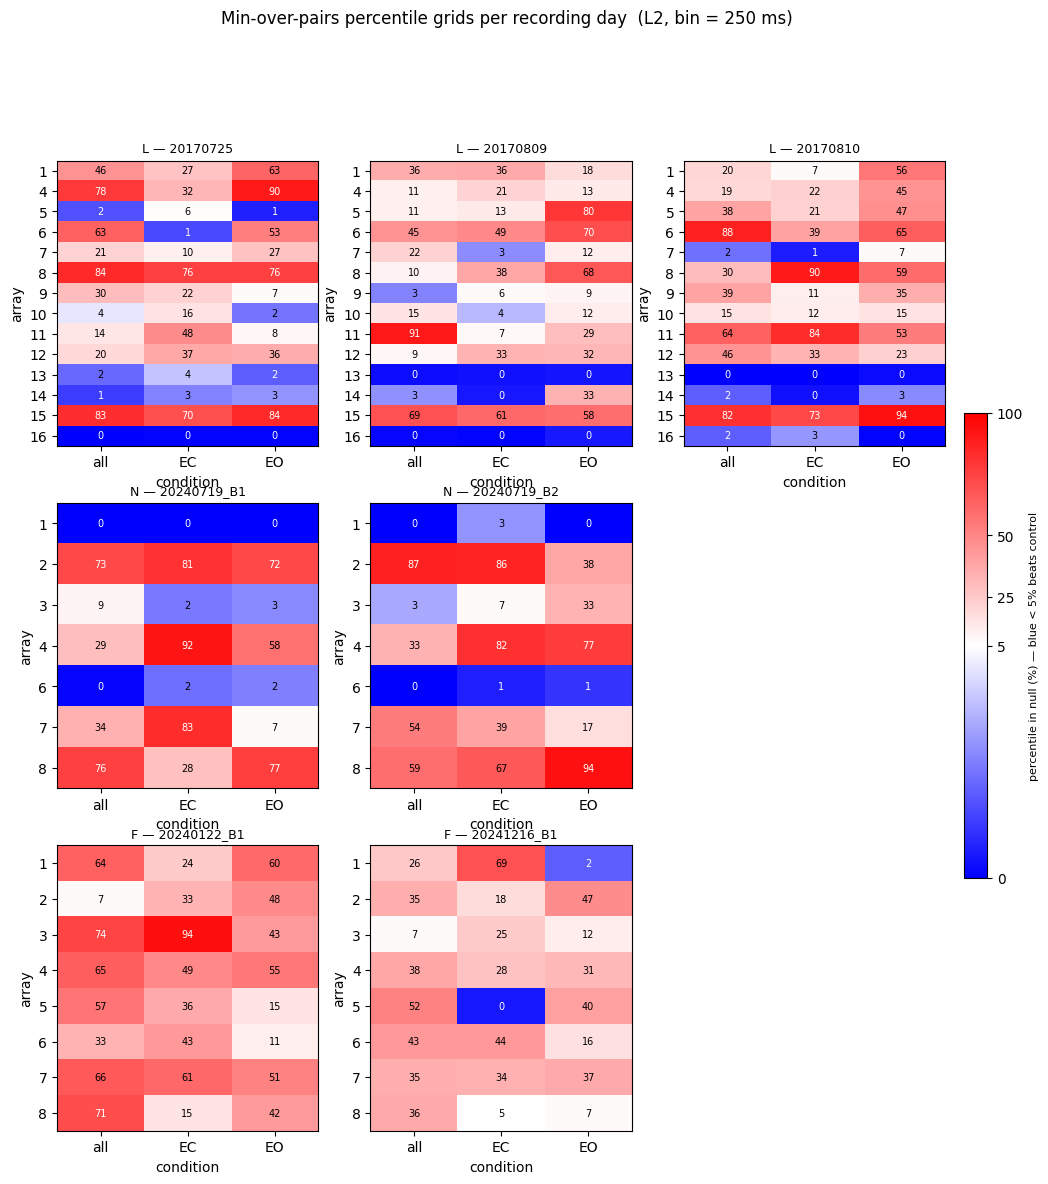

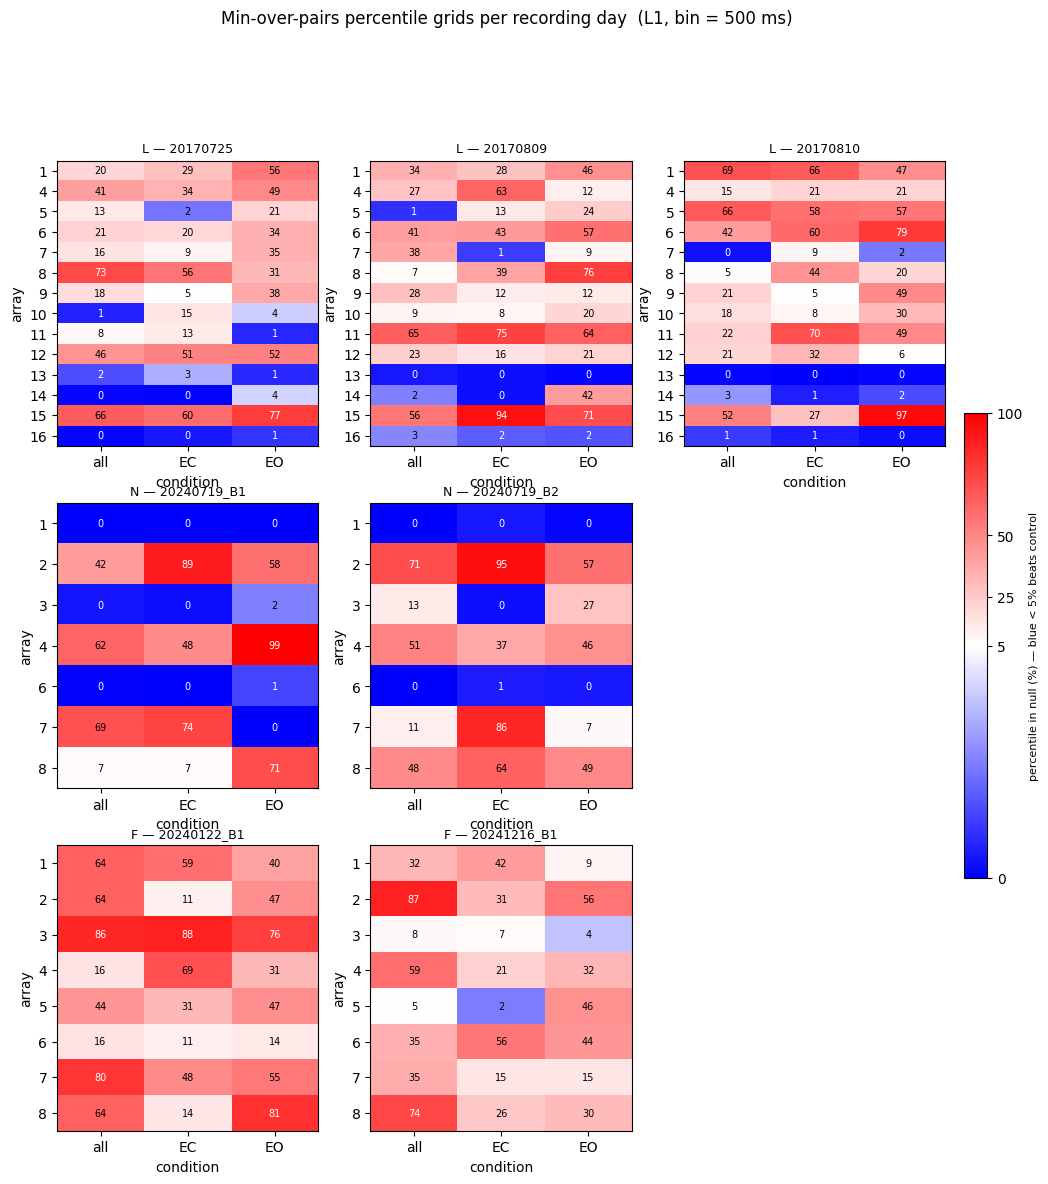

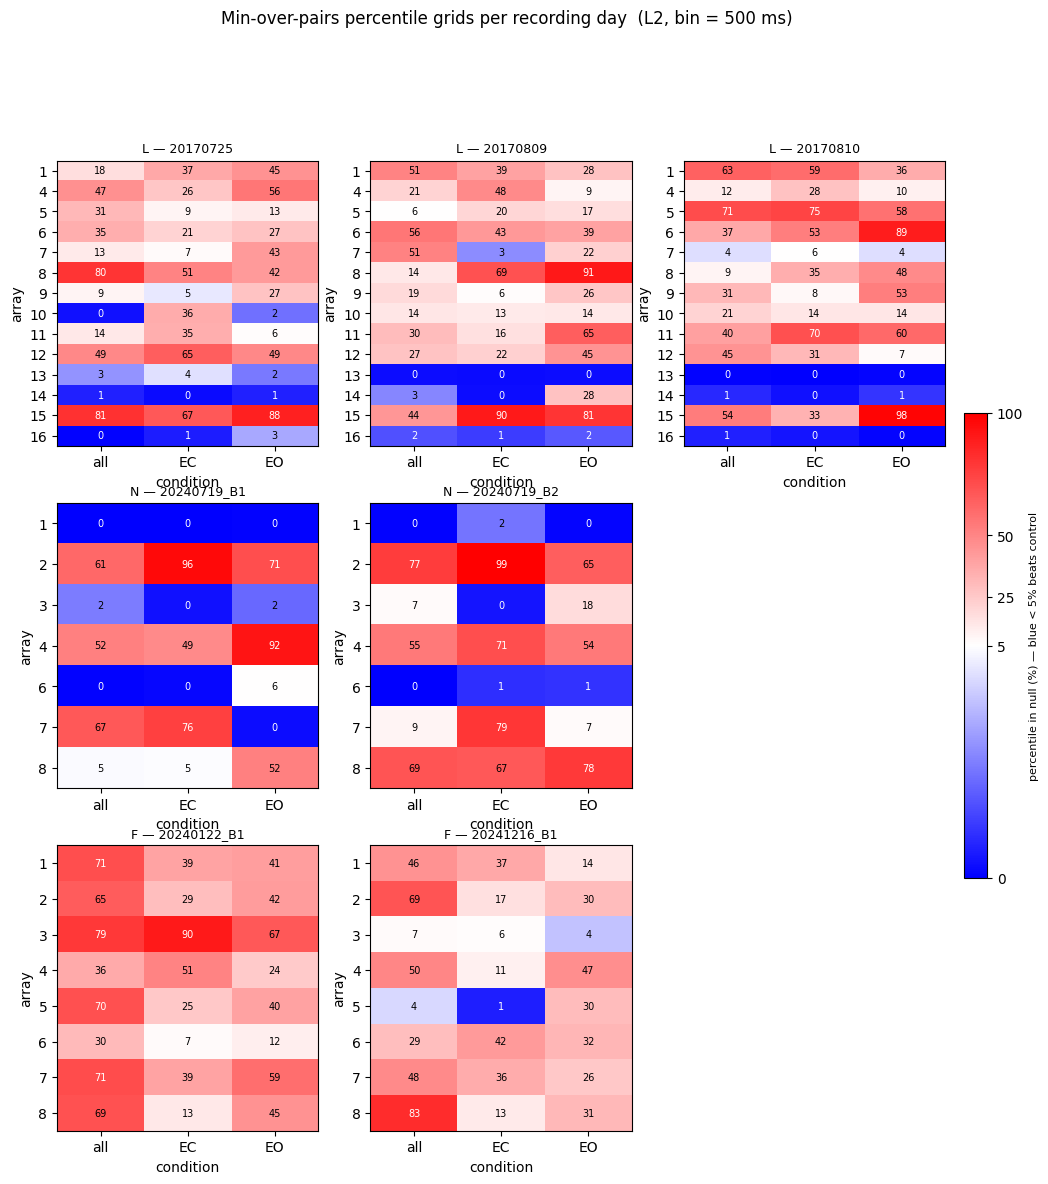

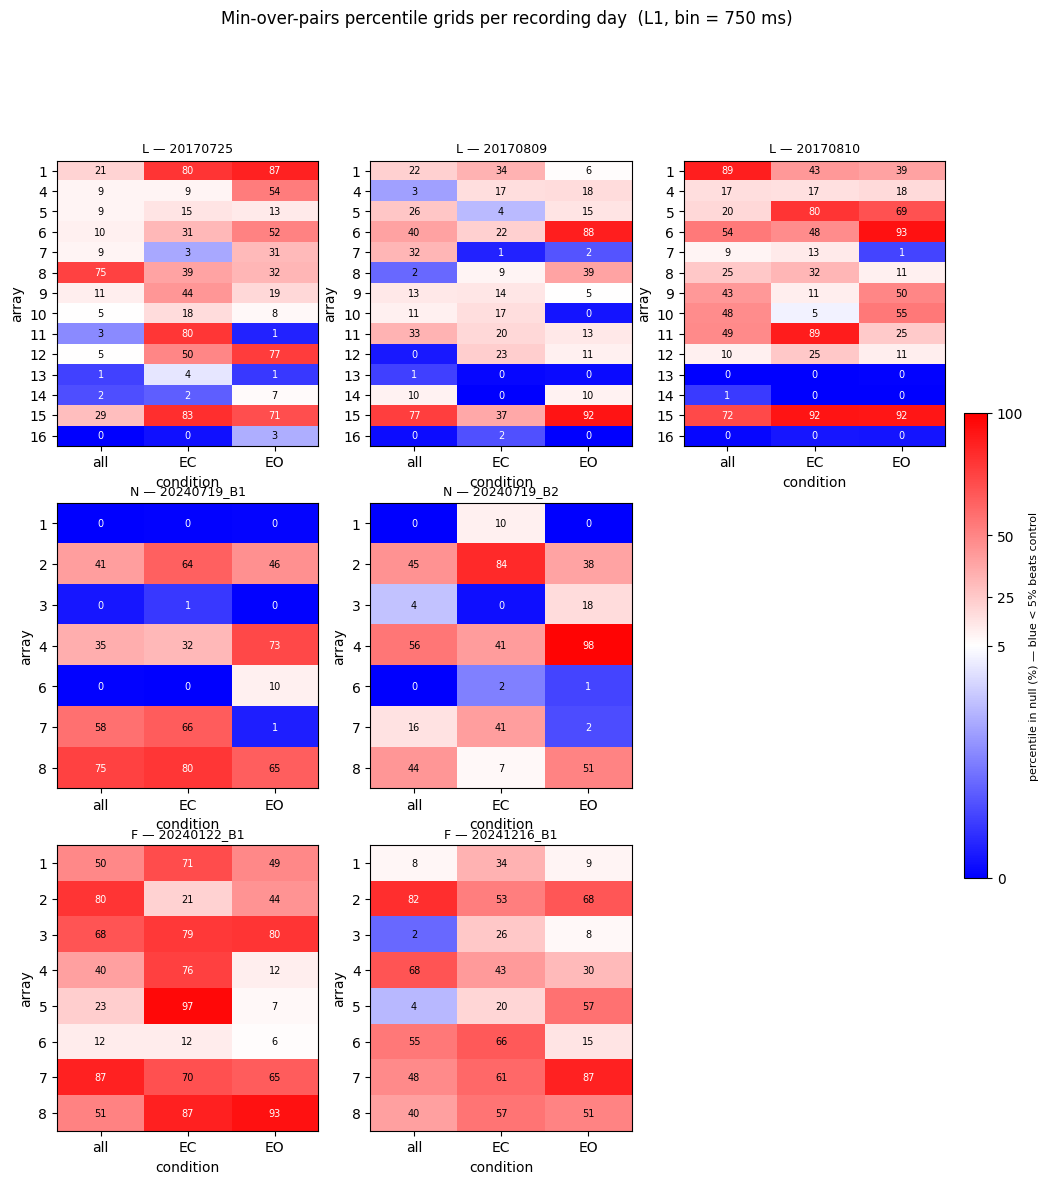

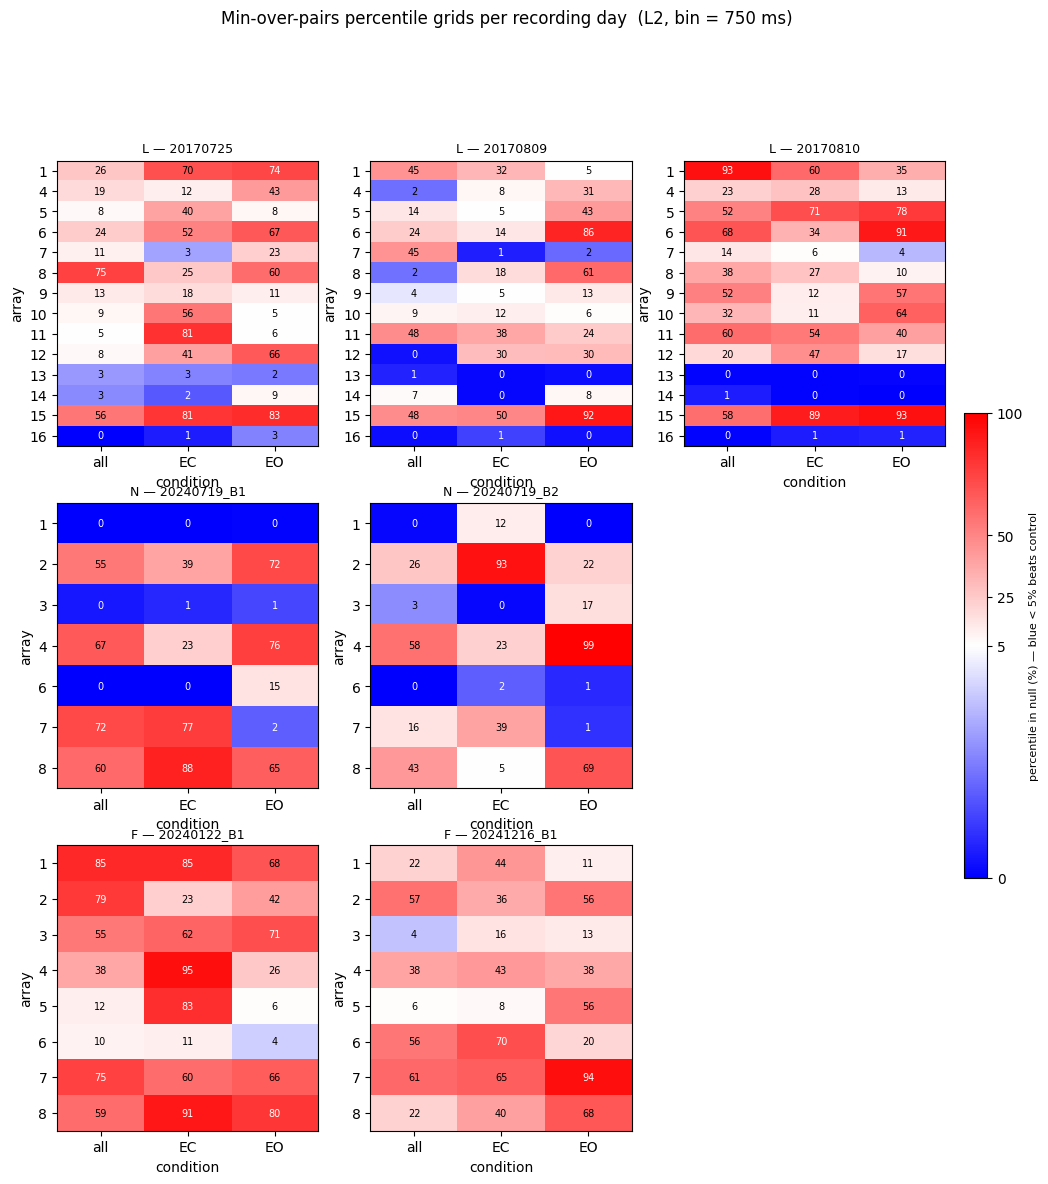

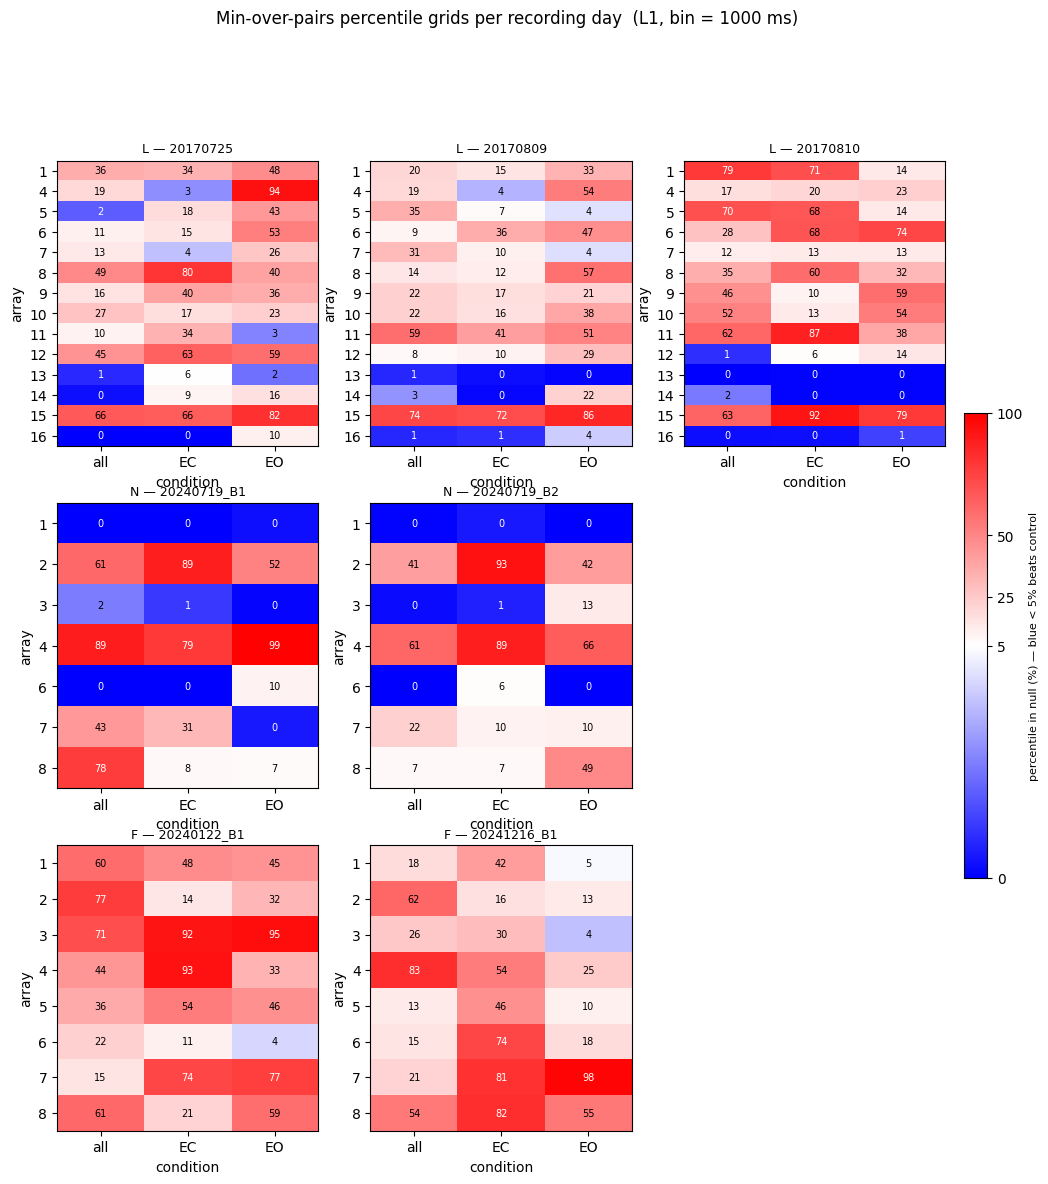

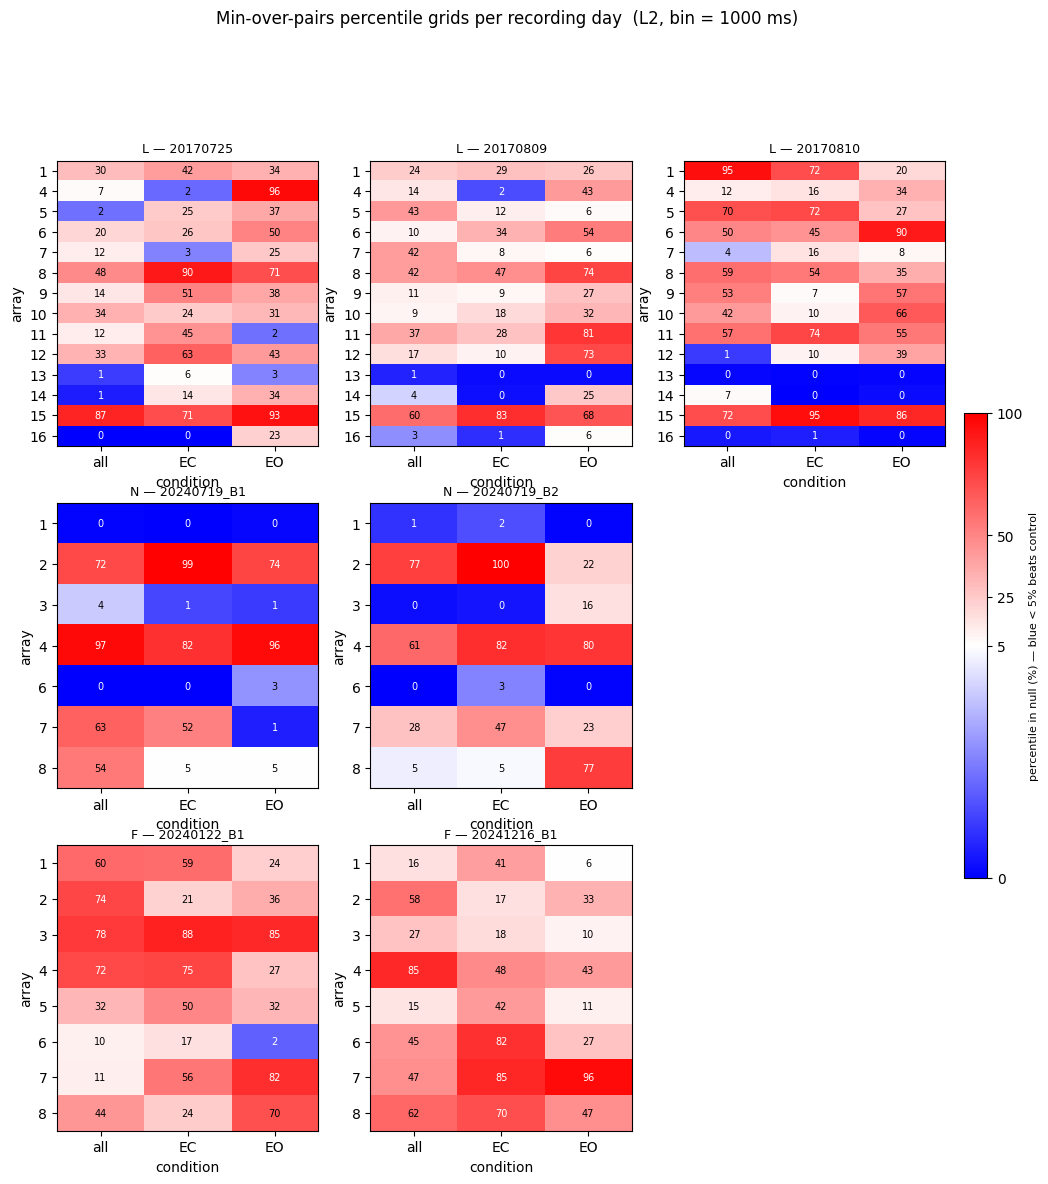

In [15]:
def grid_for_day(mp, monkey, date, norm):
    sub = mp[(mp.norm == norm) & (mp.monkey == monkey) & (mp.date == str(date))]
    conds = [c for c in ["all", "EC", "EO"] if c in sub["condition"].unique()]
    arrays = sorted(sub["array"].unique())
    grid = np.full((len(arrays), len(conds)), np.nan)
    for i, arr in enumerate(arrays):
        for j, cond in enumerate(conds):
            v = sub[(sub.array == arr) & (sub.condition == cond)]["percentile"]
            if len(v):
                grid[i, j] = v.iloc[0]      # one value per day (no averaging)
    return arrays, conds, grid

def draw_grid_day(ax, mp, monkey, date, norm):
    arrays, conds, grid = grid_for_day(mp, monkey, date, norm)
    cnorm = TwoSlopeNorm(vmin=0, vcenter=5, vmax=100)
    im = ax.imshow(grid, cmap="bwr", norm=cnorm, aspect="auto")
    ax.set_xticks(range(len(conds))); ax.set_xticklabels(conds)
    ax.set_yticks(range(len(arrays))); ax.set_yticklabels(arrays)
    ax.set_xlabel("condition"); ax.set_ylabel("array")
    ax.set_title(f"{monkey} — {date}", fontsize=9)
    for i in range(len(arrays)):
        for j in range(len(conds)):
            v = grid[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7,
                        color="white" if (v < 2 or v > 70) else "black")
    return im

monkey_dates = {m: DATES[m]["RS"] for m in MONKEYS}
max_cols = max(len(v) for v in monkey_dates.values())

for bin_plot in BIN_SIZES:
    mp_bin = minpair_percentile_df(df[df.bin_ms == bin_plot])
    for norm in ["L1", "L2"]:
        fig, axes = plt.subplots(len(MONKEYS), max_cols,
                                 figsize=(4.0*max_cols, 4.2*len(MONKEYS)),
                                 squeeze=False)
        im_last = None
        for r, monkey in enumerate(MONKEYS):
            dates = monkey_dates[monkey]
            for c in range(max_cols):
                ax = axes[r][c]
                if c < len(dates):
                    im_last = draw_grid_day(ax, mp_bin, monkey, dates[c], norm)
                else:
                    ax.axis("off")
        cbar = fig.colorbar(im_last, ax=axes, fraction=0.025, pad=0.02,
                            ticks=[0, 5, 25, 50, 100])
        cbar.set_label("percentile in null (%) — blue < 5% beats control", fontsize=8)
        fig.suptitle(f"Min-over-pairs percentile grids per recording day  "
                     f"({norm}, bin = {bin_plot} ms)", fontsize=12, y=1.0)
        plt.show()

## Boxplots — real error vs control, per PC pair

For one (monkey, date, array, condition), each box shows the control error
distribution for that PC pair; the red point is the real error. The **5th and
95th percentiles** of each control distribution are drawn as green / orange
horizontal ticks across the box (whiskers are set to the 5–95 range too).

In [5]:
def plot_pair_boxes(monkey, date, array, condition, norm, ax=None):
    sub = dfb[(dfb.monkey == monkey) & (dfb.date == str(date)) &
              (dfb.array == int(array)) & (dfb.condition == condition) &
              (dfb.norm == norm)]
    if sub.empty:
        print("no data"); return
    pairs = (sub[["pc_pair","pc_x","pc_y"]].drop_duplicates()
             .sort_values(["pc_x","pc_y"])["pc_pair"].tolist())
    ctrl_data = [sub[(sub.pc_pair==p) & (sub.source=="ctrl")]["error"].values
                 for p in pairs]
    real_vals = [sub[(sub.pc_pair==p) & (sub.source=="real")]["error"].values
                 for p in pairs]

    if ax is None:
        fig, ax = plt.subplots(figsize=(max(6, len(pairs)*0.7), 4.2))
    # whiskers at 5-95 percentile, no fliers
    bp = ax.boxplot(ctrl_data, positions=range(len(pairs)), widths=0.62,
                    whis=(5, 95), showfliers=False, patch_artist=True)
    for box in bp["boxes"]:
        box.set(facecolor="#eeeeee", edgecolor="#888888")
    for med in bp["medians"]:
        med.set(color="#555555")
    # explicit 5 / 95 percentile ticks
    for i, cd in enumerate(ctrl_data):
        if len(cd):
            p05, p95 = np.percentile(cd, 5), np.percentile(cd, 95)
            ax.hlines(p05, i-0.34, i+0.34, color="green", lw=1.6, zorder=4)
            ax.hlines(p95, i-0.34, i+0.34, color="darkorange", lw=1.6, zorder=4)
    # real error points
    for i, rv in enumerate(real_vals):
        if len(rv):
            ax.scatter(i, rv[0], color="red", s=42, zorder=5,
                       edgecolor="k", linewidth=0.5)
    ax.set_xticks(range(len(pairs)))
    ax.set_xticklabels(pairs, rotation=90, fontsize=7)
    ax.set_ylabel(f"{norm} circular error (deg)")
    ax.set_title(f"{monkey} | {date} | arr {array} | {condition} | bin {BIN_MS}ms",
                 fontsize=9)
    # legend proxies
    from matplotlib.lines import Line2D
    ax.legend(handles=[
        Line2D([0],[0], color="red", marker="o", ls="", label="real"),
        Line2D([0],[0], color="green", lw=2, label="ctrl 5th pct"),
        Line2D([0],[0], color="darkorange", lw=2, label="ctrl 95th pct")],
        fontsize=7, loc="upper right")
    return ax

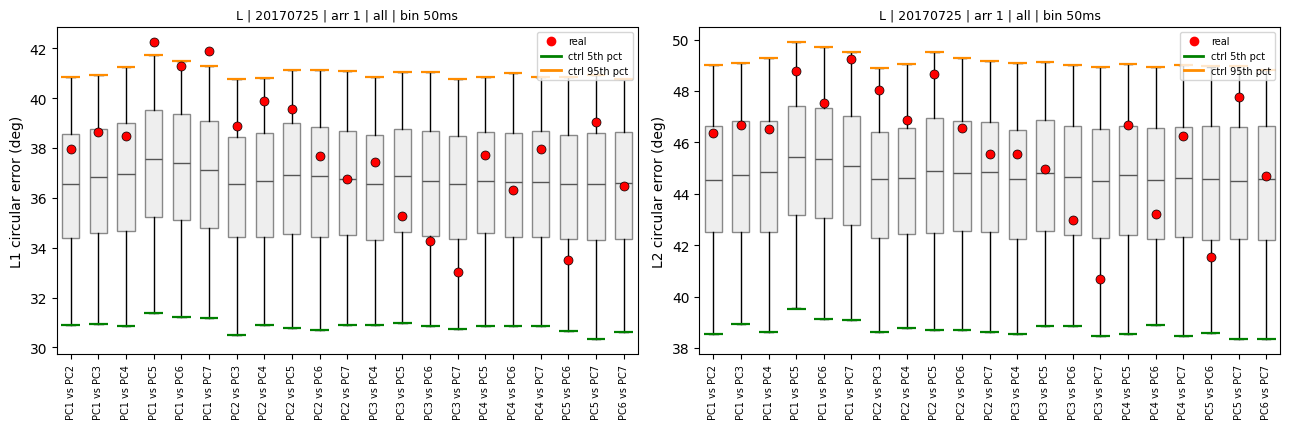

In [6]:
# example — L1 vs L2 side by side for one cell
m  = "L"; d = DATES["L"]["RS"][0]; a = V1_ARRAYS["L"][0]; cond = "all"
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
plot_pair_boxes(m, d, a, cond, "L1", ax=axes[0])
plot_pair_boxes(m, d, a, cond, "L2", ax=axes[1])
plt.tight_layout(); plt.show()

## The optimal (min-over-pairs) control distribution

This is the distribution the improved test actually compares against: for each
control map we take its **best error across all PC pairs**, giving one null
distribution per cell. The histogram shows that null; the red line is the real
best-of-pairs error; green / orange dashed lines mark the 5th / 95th percentiles
of the null. Shown for L1 and L2.

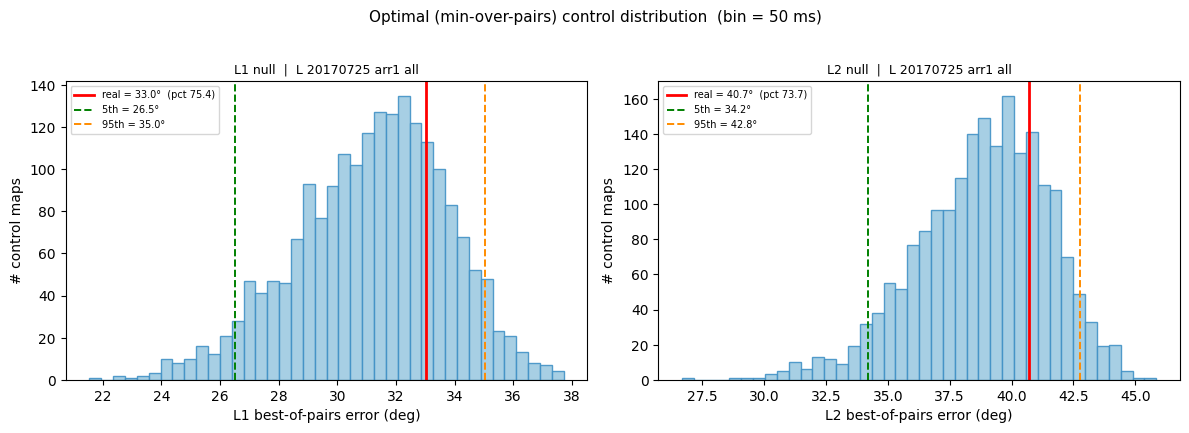

In [7]:
def min_over_pairs_null(monkey, date, array, condition, norm):
    sub = dfb[(dfb.monkey == monkey) & (dfb.date == str(date)) &
              (dfb.array == int(array)) & (dfb.condition == condition) &
              (dfb.norm == norm)]
    real_min = sub[sub.source == "real"]["error"].min()
    ctrl = sub[sub.source == "ctrl"]
    null = ctrl.groupby("ctrl_idx")["error"].min().to_numpy()   # best per control
    return real_min, null

def plot_optimal_null(monkey, date, array, condition, ax, norm):
    real_min, null = min_over_pairs_null(monkey, date, array, condition, norm)
    if not len(null):
        print("no control data"); return
    p05, p95 = np.percentile(null, 5), np.percentile(null, 95)
    pct = 100.0 * np.mean(null <= real_min)
    ax.hist(null, bins=40, color="#9ecae1", edgecolor="#4292c6", alpha=0.9)
    ax.axvline(real_min, color="red", lw=2,
               label=f"real = {real_min:.1f}°  (pct {pct:.1f})")
    ax.axvline(p05, color="green", ls="--", lw=1.4, label=f"5th = {p05:.1f}°")
    ax.axvline(p95, color="darkorange", ls="--", lw=1.4, label=f"95th = {p95:.1f}°")
    ax.set_xlabel(f"{norm} best-of-pairs error (deg)")
    ax.set_ylabel("# control maps")
    ax.set_title(f"{norm} null  |  {monkey} {date} arr{array} {condition}", fontsize=9)
    ax.legend(fontsize=7)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
plot_optimal_null(m, d, a, cond, axes[0], "L1")
plot_optimal_null(m, d, a, cond, axes[1], "L2")
plt.suptitle(f"Optimal (min-over-pairs) control distribution  (bin = {BIN_MS} ms)",
             y=1.02, fontsize=11)
plt.tight_layout(); plt.show()

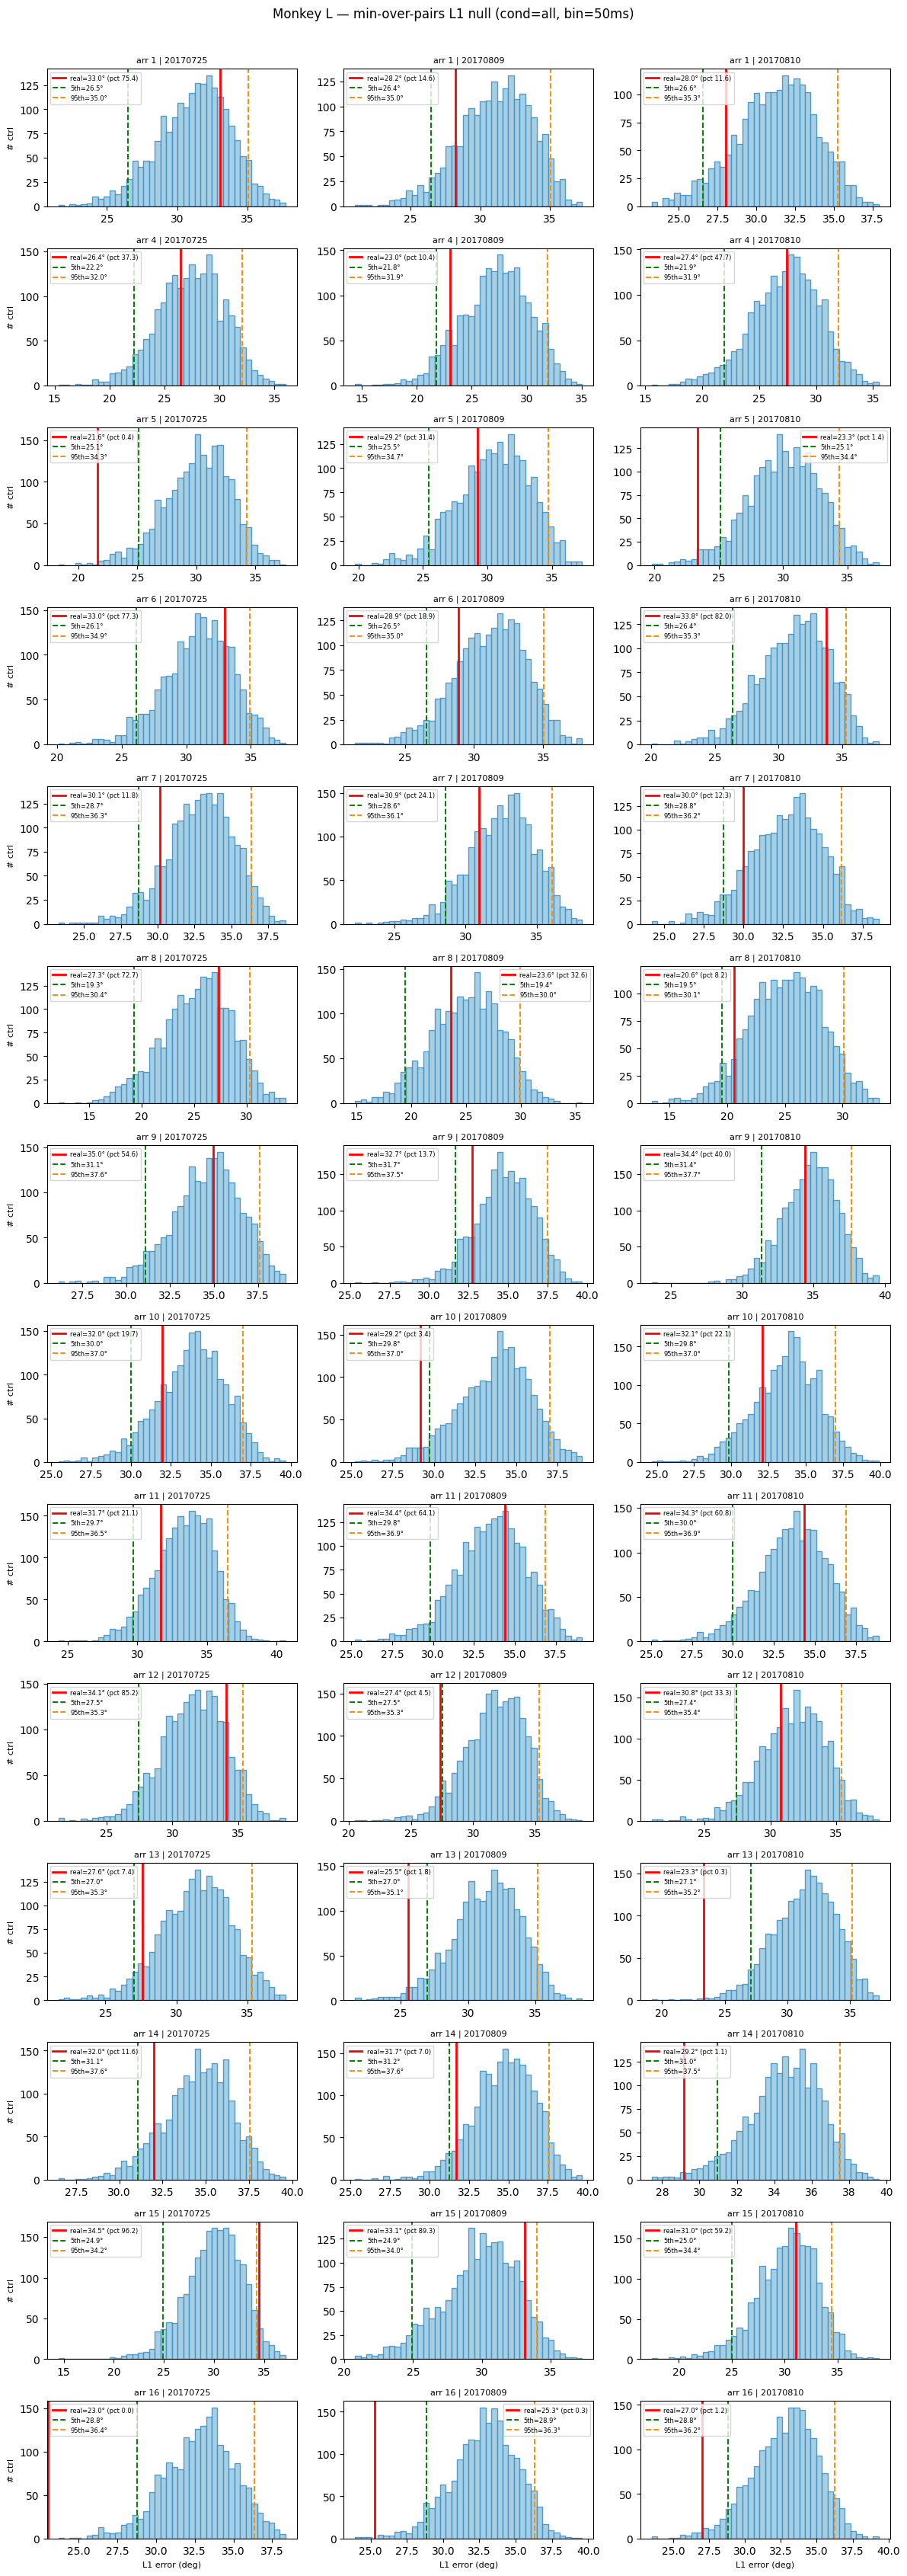

In [12]:
MONKEY = "L" 
NORM = "L1"
COND = "all"

# one filter + one groupby up front
d = dfb[(dfb.monkey == MONKEY) & (dfb.condition == COND) & (dfb.norm == NORM)]
real_g = (d[d.source == "real"].groupby(["array","date"])["error"].min())
ctrl_g = (d[d.source == "ctrl"].groupby(["array","date","ctrl_idx"])["error"].min()
          .groupby(level=["array","date"]).apply(lambda s: s.to_numpy()))

arrays = V1_ARRAYS[MONKEY]; dates = DATES[MONKEY]["RS"]
fig, axes = plt.subplots(len(arrays), len(dates),
                         figsize=(4.0*len(dates), 2.4*len(arrays)), squeeze=False)

for i, array in enumerate(arrays):
    for j, date in enumerate(dates):
        ax = axes[i][j]
        key = (int(array), str(date))
        if key not in real_g.index or key not in ctrl_g.index:
            ax.text(0.5, 0.5, "no data", ha="center", va="center",
                    fontsize=8, color="grey", transform=ax.transAxes)
            ax.set_xticks([]); ax.set_yticks([]); continue
        real_min = real_g.loc[key]
        null = ctrl_g.loc[key]
        p05, p95 = np.percentile(null, 5), np.percentile(null, 95)
        pct = 100.0 * np.mean(null <= real_min)
        ax.hist(null, bins=40, color="#9ecae1", edgecolor="#4292c6", alpha=0.9)
        ax.axvline(real_min, color="red", lw=2, label=f"real={real_min:.1f}° (pct {pct:.1f})")
        ax.axvline(p05, color="green", ls="--", lw=1.4, label=f"5th={p05:.1f}°")
        ax.axvline(p95, color="darkorange", ls="--", lw=1.4, label=f"95th={p95:.1f}°")
        ax.set_title(f"arr {array} | {date}", fontsize=8)
        ax.legend(fontsize=6)
        if j == 0: ax.set_ylabel("# ctrl", fontsize=8)
        if i == len(arrays)-1: ax.set_xlabel(f"{NORM} error (deg)", fontsize=8)

fig.suptitle(f"Monkey {MONKEY} — min-over-pairs {NORM} null (cond={COND}, bin={BIN_MS}ms)",
             fontsize=12, y=1.005)
plt.tight_layout(); plt.show()

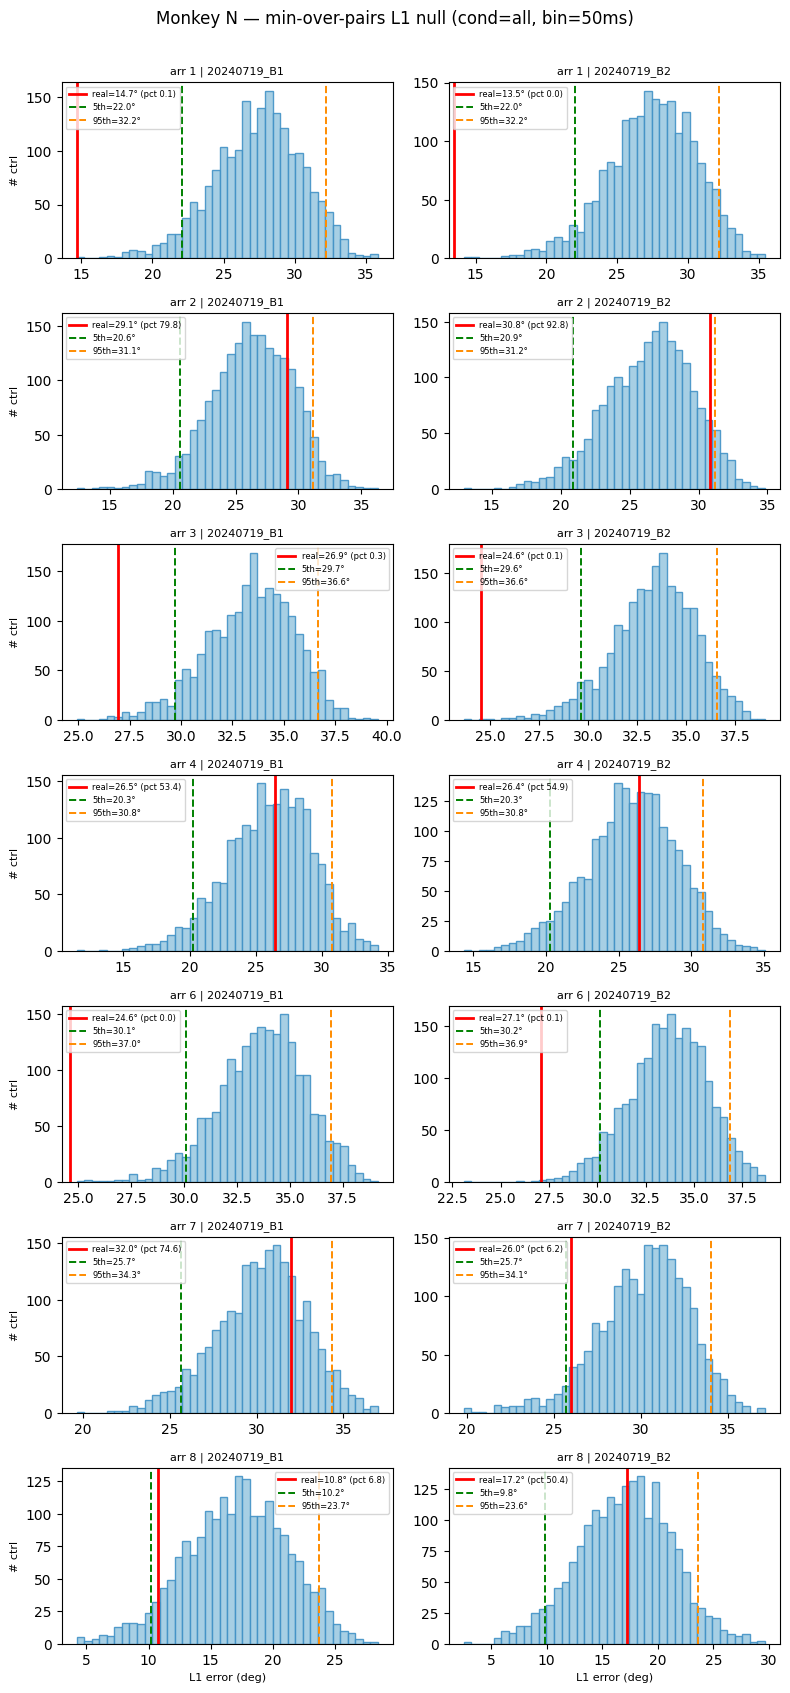

In [13]:
MONKEY = "N" 
NORM = "L1"
COND = "all"

# one filter + one groupby up front
d = dfb[(dfb.monkey == MONKEY) & (dfb.condition == COND) & (dfb.norm == NORM)]
real_g = (d[d.source == "real"].groupby(["array","date"])["error"].min())
ctrl_g = (d[d.source == "ctrl"].groupby(["array","date","ctrl_idx"])["error"].min()
          .groupby(level=["array","date"]).apply(lambda s: s.to_numpy()))

arrays = V1_ARRAYS[MONKEY]; dates = DATES[MONKEY]["RS"]
fig, axes = plt.subplots(len(arrays), len(dates),
                         figsize=(4.0*len(dates), 2.4*len(arrays)), squeeze=False)

for i, array in enumerate(arrays):
    for j, date in enumerate(dates):
        ax = axes[i][j]
        key = (int(array), str(date))
        if key not in real_g.index or key not in ctrl_g.index:
            ax.text(0.5, 0.5, "no data", ha="center", va="center",
                    fontsize=8, color="grey", transform=ax.transAxes)
            ax.set_xticks([]); ax.set_yticks([]); continue
        real_min = real_g.loc[key]
        null = ctrl_g.loc[key]
        p05, p95 = np.percentile(null, 5), np.percentile(null, 95)
        pct = 100.0 * np.mean(null <= real_min)
        ax.hist(null, bins=40, color="#9ecae1", edgecolor="#4292c6", alpha=0.9)
        ax.axvline(real_min, color="red", lw=2, label=f"real={real_min:.1f}° (pct {pct:.1f})")
        ax.axvline(p05, color="green", ls="--", lw=1.4, label=f"5th={p05:.1f}°")
        ax.axvline(p95, color="darkorange", ls="--", lw=1.4, label=f"95th={p95:.1f}°")
        ax.set_title(f"arr {array} | {date}", fontsize=8)
        ax.legend(fontsize=6)
        if j == 0: ax.set_ylabel("# ctrl", fontsize=8)
        if i == len(arrays)-1: ax.set_xlabel(f"{NORM} error (deg)", fontsize=8)

fig.suptitle(f"Monkey {MONKEY} — min-over-pairs {NORM} null (cond={COND}, bin={BIN_MS}ms)",
             fontsize=12, y=1.005)
plt.tight_layout(); plt.show()

## L1 vs L2 percentile agreement

Across all cells at this bin, do the two norms give similar percentiles?
Each point is one (monkey, date, array, condition); colour by monkey.

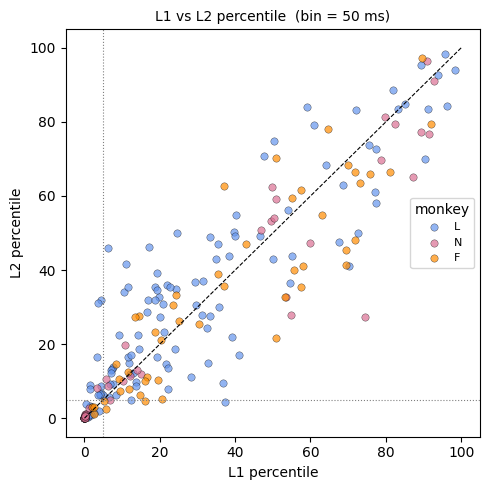

In [8]:
piv = (mp.pivot_table(index=["monkey","date","array","condition"],
                      columns="norm", values="percentile").reset_index())
if {"L1","L2"}.issubset(piv.columns):
    fig, ax = plt.subplots(figsize=(5, 5))
    for monkey in MONKEYS:
        s = piv[piv.monkey == monkey]
        ax.scatter(s["L1"], s["L2"], s=28, alpha=0.7,
                   color=COLORS_M.get(monkey,"gray"), label=monkey,
                   edgecolor="k", linewidth=0.3)
    ax.plot([0,100],[0,100], "k--", lw=0.8)
    ax.axhline(5, color="grey", ls=":", lw=0.8); ax.axvline(5, color="grey", ls=":", lw=0.8)
    ax.set_xlabel("L1 percentile"); ax.set_ylabel("L2 percentile")
    ax.set_title(f"L1 vs L2 percentile  (bin = {BIN_MS} ms)", fontsize=10)
    ax.legend(title="monkey", fontsize=8)
    plt.tight_layout(); plt.show()
else:
    print("need both L1 and L2")

## Bin-size sweep — fraction of significant cells

How does the FR bin size affect reconstruction? For each bin and norm, the
fraction of (array, date, condition) cells whose real best-pair error falls
below the 5th percentile of its control null (percentile < 5).

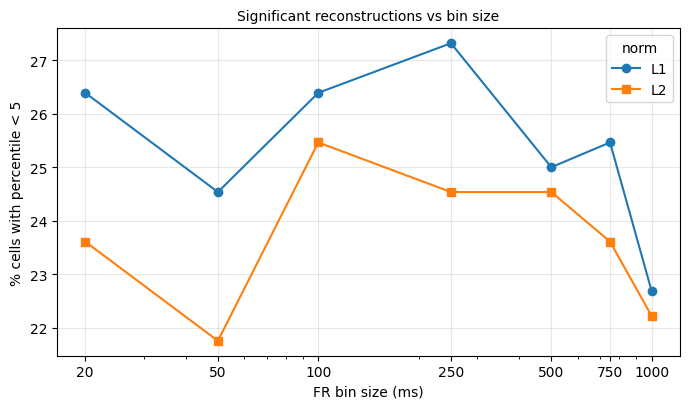

,bin_ms,norm,frac_sig,n
0,20,L1,0.263889,216
1,20,L2,0.236111,216
2,50,L1,0.245370,216
3,50,L2,0.217593,216
4,100,L1,0.263889,216
5,100,L2,0.254630,216
6,250,L1,0.273148,216
7,250,L2,0.245370,216
8,500,L1,0.250000,216
9,500,L2,0.245370,216


In [9]:
def frac_significant_by_bin(df, thresh=5.0):
    recs = []
    for bm in sorted(df["bin_ms"].unique()):
        mp_bin = minpair_percentile_df(df[df.bin_ms == bm])
        for norm in ["L1", "L2"]:
            s = mp_bin[mp_bin.norm == norm]["percentile"].dropna()
            frac = float(np.mean(s < thresh)) if len(s) else np.nan
            recs.append(dict(bin_ms=bm, norm=norm, frac_sig=frac, n=len(s)))
    return pd.DataFrame(recs)

fsb = frac_significant_by_bin(df)
fig, ax = plt.subplots(figsize=(7, 4.2))
for norm, mark in [("L1","o"), ("L2","s")]:
    s = fsb[fsb.norm == norm]
    ax.plot(s["bin_ms"], 100*s["frac_sig"], marker=mark, label=norm)
ax.set_xscale("log")
ax.set_xticks(BIN_SIZES); ax.set_xticklabels(BIN_SIZES)
ax.set_xlabel("FR bin size (ms)"); ax.set_ylabel("% cells with percentile < 5")
ax.set_title("Significant reconstructions vs bin size", fontsize=10)
ax.legend(title="norm"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
fsb

## Significance VS number of electordes

In [16]:
# n_oriented per (monkey, date, array, condition) from the saved PCA scores
with open(os.path.join(DF_FOLDER, "pca_scores_binsweep.pkl"), "rb") as f:
    pca_store = pickle.load(f)

rows = []
for (monkey, date, array, condition, bin_ms), st in pca_store.items():
    rows.append(dict(monkey=monkey, date=date, array=int(array),
                     condition=condition, bin_ms=int(bin_ms),
                     n_oriented=len(st["oriented_idx"])))
n_or_df = pd.DataFrame(rows).drop_duplicates()

# attach n_oriented to the min-over-pairs percentile table (pick a bin to study)
BIN_STUDY = 100
mp_study = minpair_percentile_df(df[df.bin_ms == BIN_STUDY])
merged = mp_study.merge(
    n_or_df[n_or_df.bin_ms == BIN_STUDY][
        ["monkey","date","array","condition","n_oriented"]],
    on=["monkey","date","array","condition"], how="left")
print("merged rows:", len(merged), "| n_oriented range:",
      int(merged.n_oriented.min()), "-", int(merged.n_oriented.max()))
merged.head()

merged rows: 432 | n_oriented range: 5 - 46


,monkey,date,array,condition,bin_ms,norm,real_error,pc_pair,pc_x,pc_y,percentile,null_mean,null_p05,null_p95,n_ctrl,n_oriented
0,F,20240122_B1,1,EC,100,L1,24.028986,PC2 vs PC3,2,3,18.60,26.769201,21.599930,31.520823,2000,15
1,F,20240122_B1,1,EC,100,L2,32.100911,PC2 vs PC3,2,3,25.15,34.264163,28.021282,39.437925,2000,15
2,F,20240122_B1,1,EO,100,L1,28.693653,PC5 vs PC6,5,6,71.45,26.753617,20.932511,31.623078,2000,15
3,F,20240122_B1,1,EO,100,L2,33.668019,PC4 vs PC5,4,5,40.10,34.242127,27.537829,39.610076,2000,15
4,F,20240122_B1,1,all,100,L1,30.602808,PC1 vs PC5,1,5,90.45,26.794354,21.251502,31.383068,2000,15


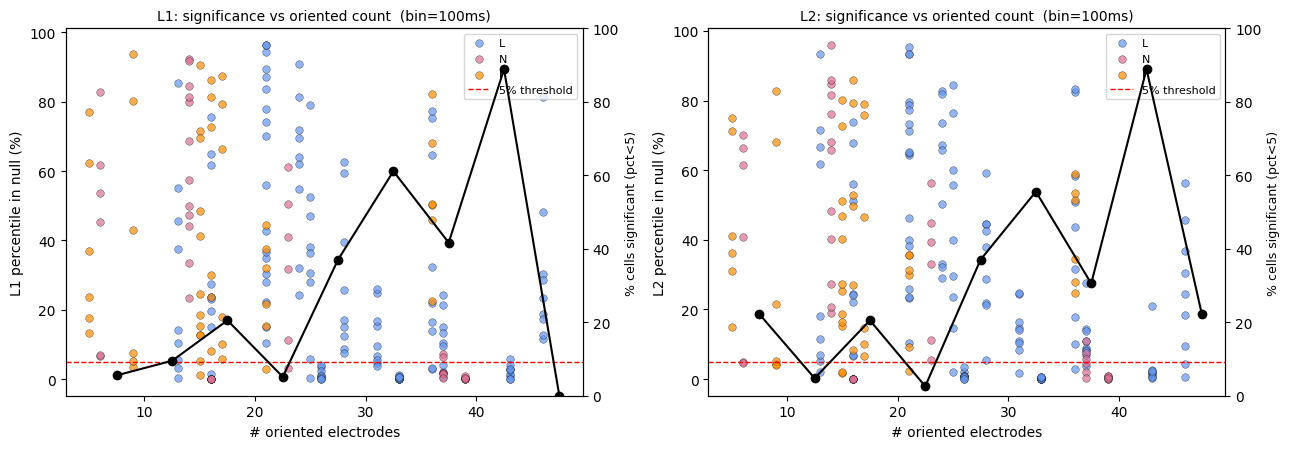

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, norm in zip(axes, ["L1", "L2"]):
    s = merged[merged.norm == norm].dropna(subset=["n_oriented","percentile"])
    # colour significant (pct<5) vs not
    sig = s.percentile < 5
    for monkey in MONKEYS:
        ms = s[s.monkey == monkey]
        ax.scatter(ms["n_oriented"], ms["percentile"], s=30, alpha=0.7,
                   color=COLORS_M.get(monkey, "gray"), label=monkey,
                   edgecolor="k", linewidth=0.3)
    ax.axhline(5, color="red", ls="--", lw=1, label="5% threshold")
    ax.set_xlabel("# oriented electrodes")
    ax.set_ylabel(f"{norm} percentile in null (%)")
    ax.set_title(f"{norm}: significance vs oriented count  (bin={BIN_STUDY}ms)",
                 fontsize=10)
    ax.legend(fontsize=8)

    # fraction significant in n_oriented bins, overlaid on a twin axis
    edges = np.arange(0, s["n_oriented"].max()+6, 5)
    cats = pd.cut(s["n_oriented"], edges, right=False)
    frac = s.groupby(cats, observed=True).apply(
        lambda g: np.mean(g.percentile < 5))
    centers = [iv.left + 2.5 for iv in frac.index]
    ax2 = ax.twinx()
    ax2.plot(centers, 100*frac.values, color="black", marker="o", lw=1.5,
             label="% significant")
    ax2.set_ylabel("% cells significant (pct<5)", fontsize=9)
    ax2.set_ylim(0, 100)
plt.tight_layout(); plt.show()

Smallest oriented count yielding a significant (L1) cell: 9
10th percentile of oriented counts among significant cells: 16
Arrays below that cutoff: 2 of 29


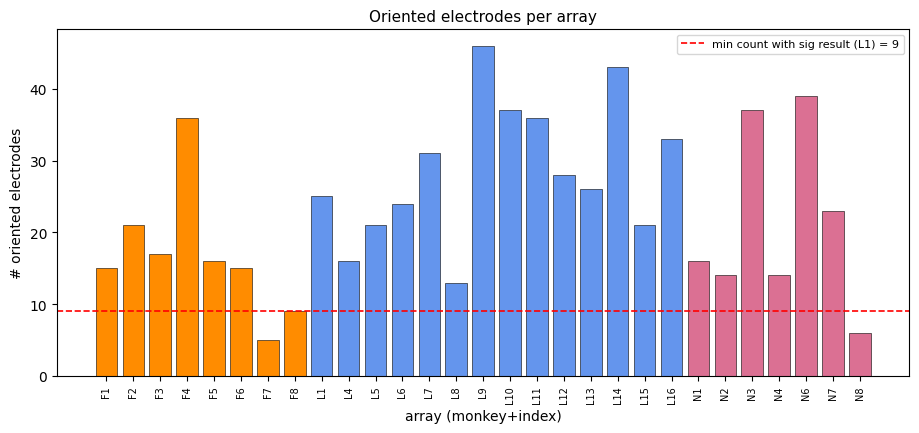

In [18]:
# one count per array (oriented count is stable across days/conditions; take the max seen)
per_array = (n_or_df.groupby(["monkey","array"])["n_oriented"].max()
             .reset_index().sort_values(["monkey","array"]))

fig, ax = plt.subplots(figsize=(11, 4.5))
xpos = np.arange(len(per_array))
colors = [COLORS_M.get(m, "gray") for m in per_array["monkey"]]
ax.bar(xpos, per_array["n_oriented"], color=colors, edgecolor="k", linewidth=0.4)
ax.set_xticks(xpos)
ax.set_xticklabels([f"{m}{a}" for m, a in
                    zip(per_array["monkey"], per_array["array"])],
                   rotation=90, fontsize=7)
ax.set_ylabel("# oriented electrodes")
ax.set_xlabel("array (monkey+index)")
ax.set_title("Oriented electrodes per array", fontsize=11)

# suggest a cutoff: smallest count at which significant cells start appearing
sig_counts = merged[(merged.norm=="L1") & (merged.percentile < 5)]["n_oriented"]
if len(sig_counts):
    min_sig = int(sig_counts.min())
    p10_sig = int(np.percentile(sig_counts, 10))
    ax.axhline(min_sig, color="red", ls="--", lw=1.2,
               label=f"min count with sig result (L1) = {min_sig}")
    ax.legend(fontsize=8)
    print(f"Smallest oriented count yielding a significant (L1) cell: {min_sig}")
    print(f"10th percentile of oriented counts among significant cells: {p10_sig}")
n_excluded = (per_array["n_oriented"] < (min_sig if len(sig_counts) else 0)).sum()
print(f"Arrays below that cutoff: {n_excluded} of {len(per_array)}")

## Significance grids only for arrays with high enough number of electrodes

arrays kept (> 20 oriented):
  L: [1, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15, 16]
  N: [3, 6, 7]
  F: [2, 4]


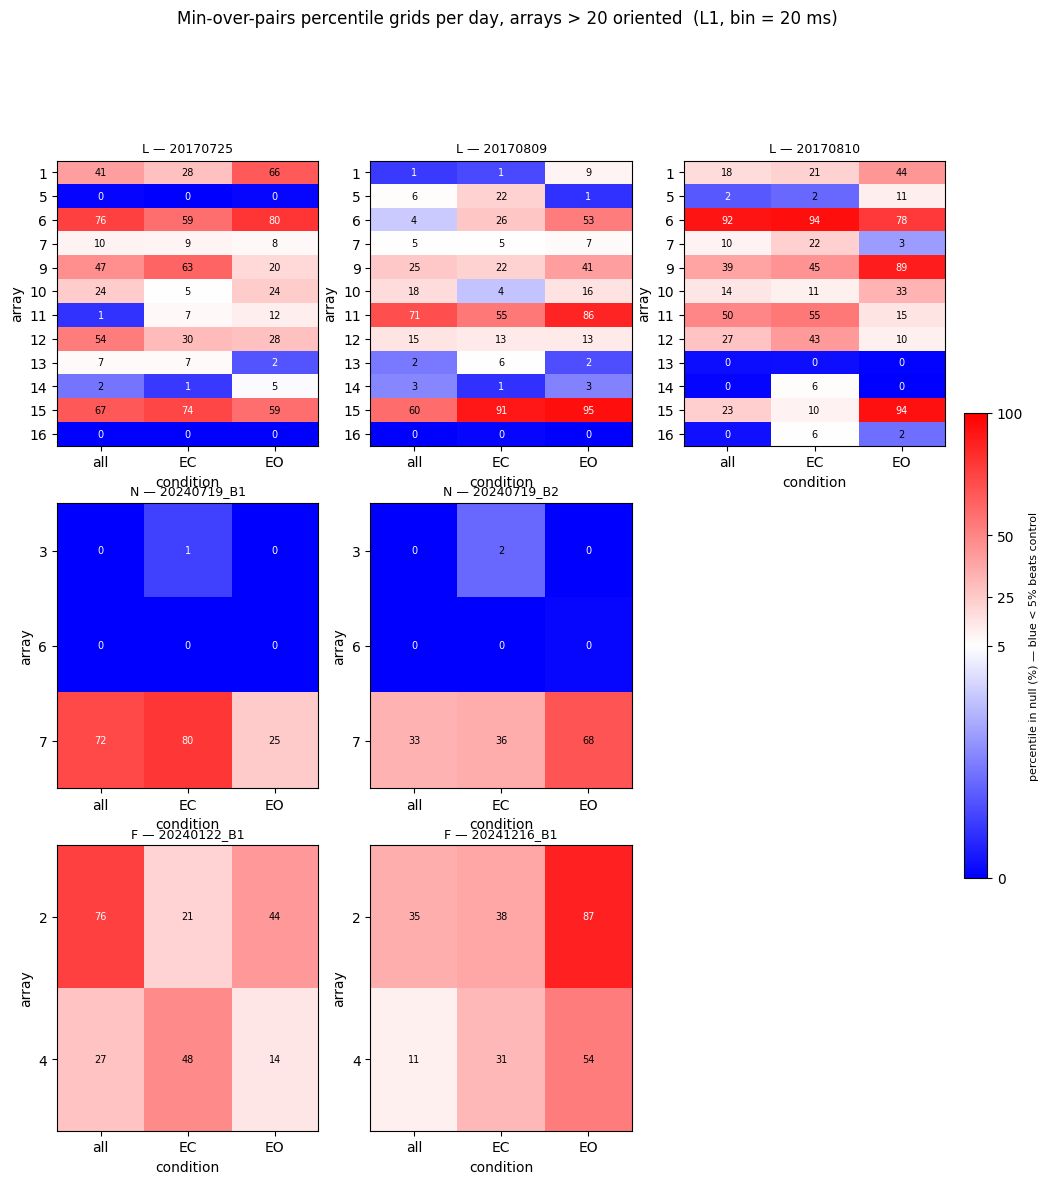

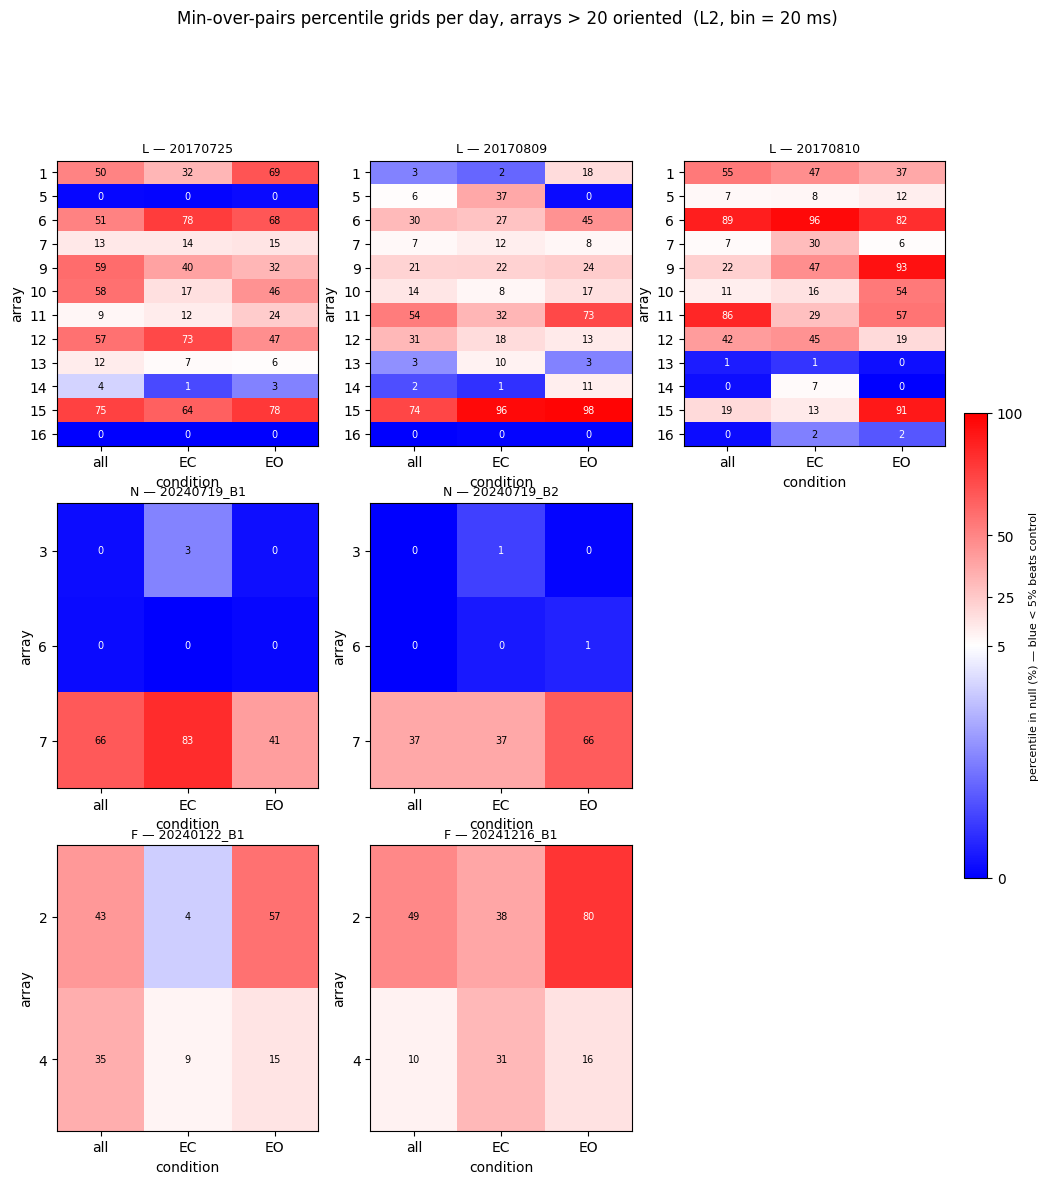

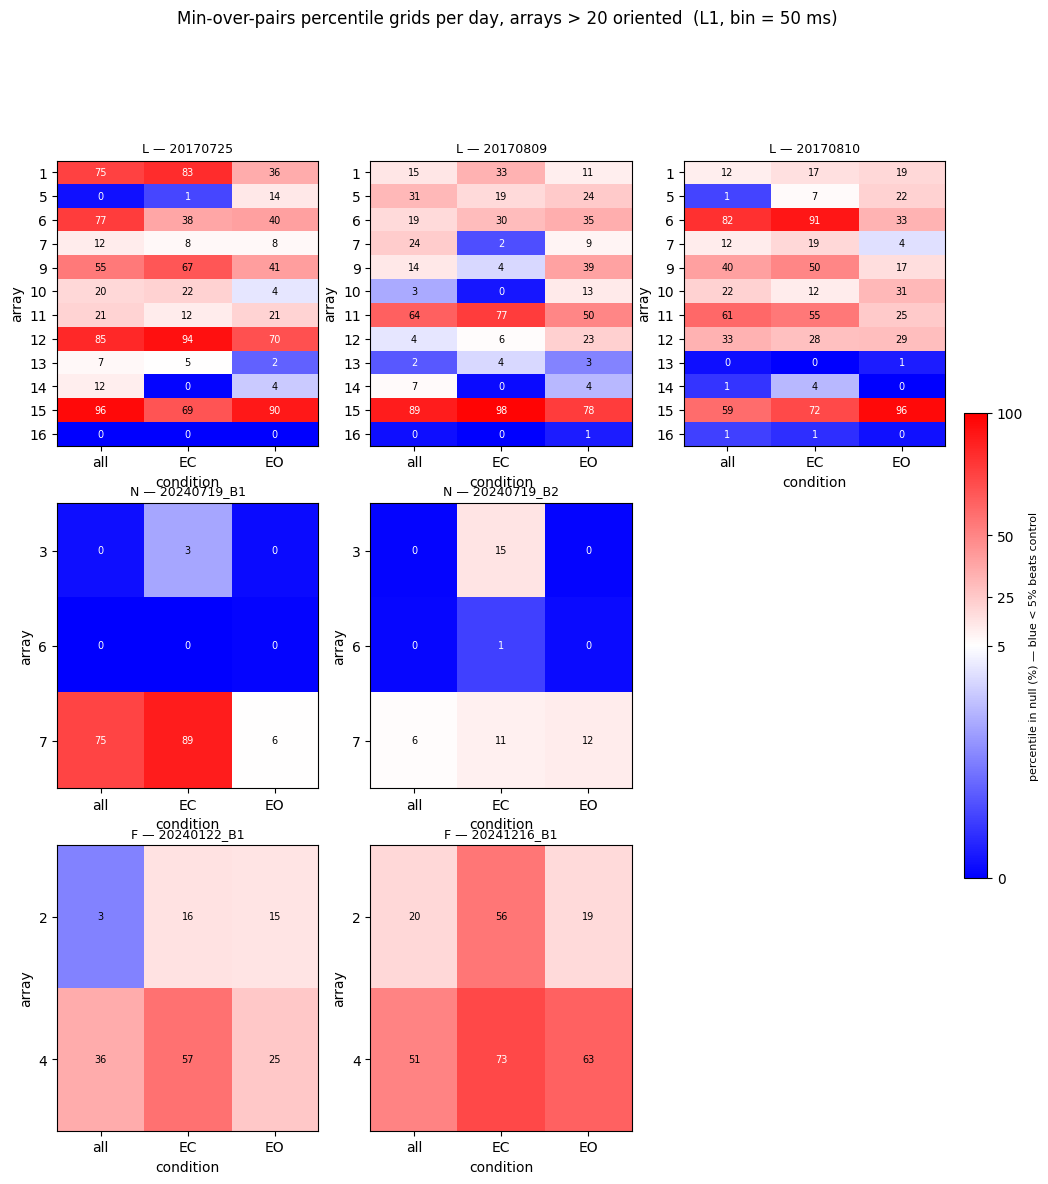

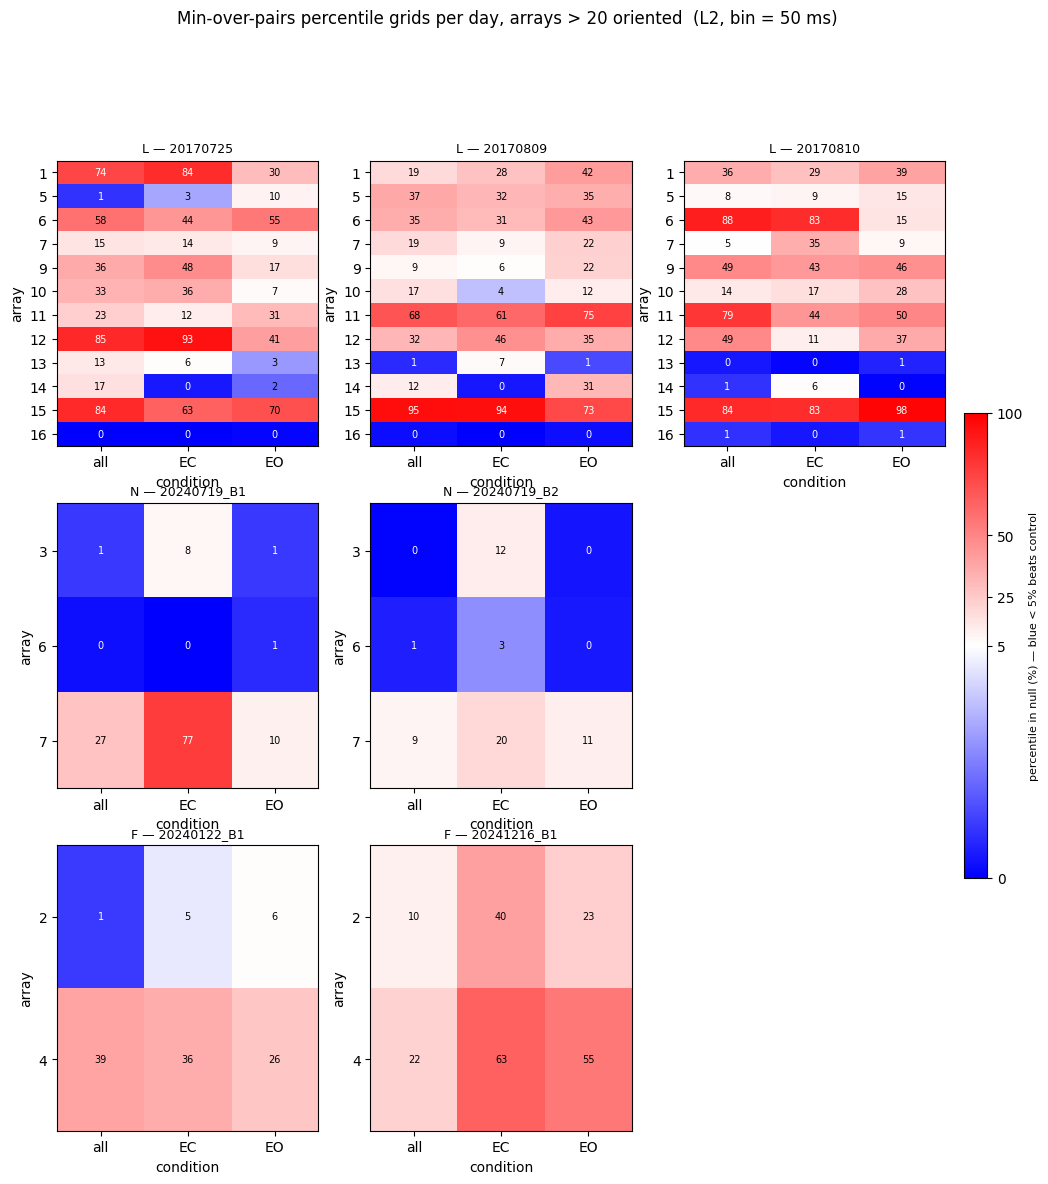

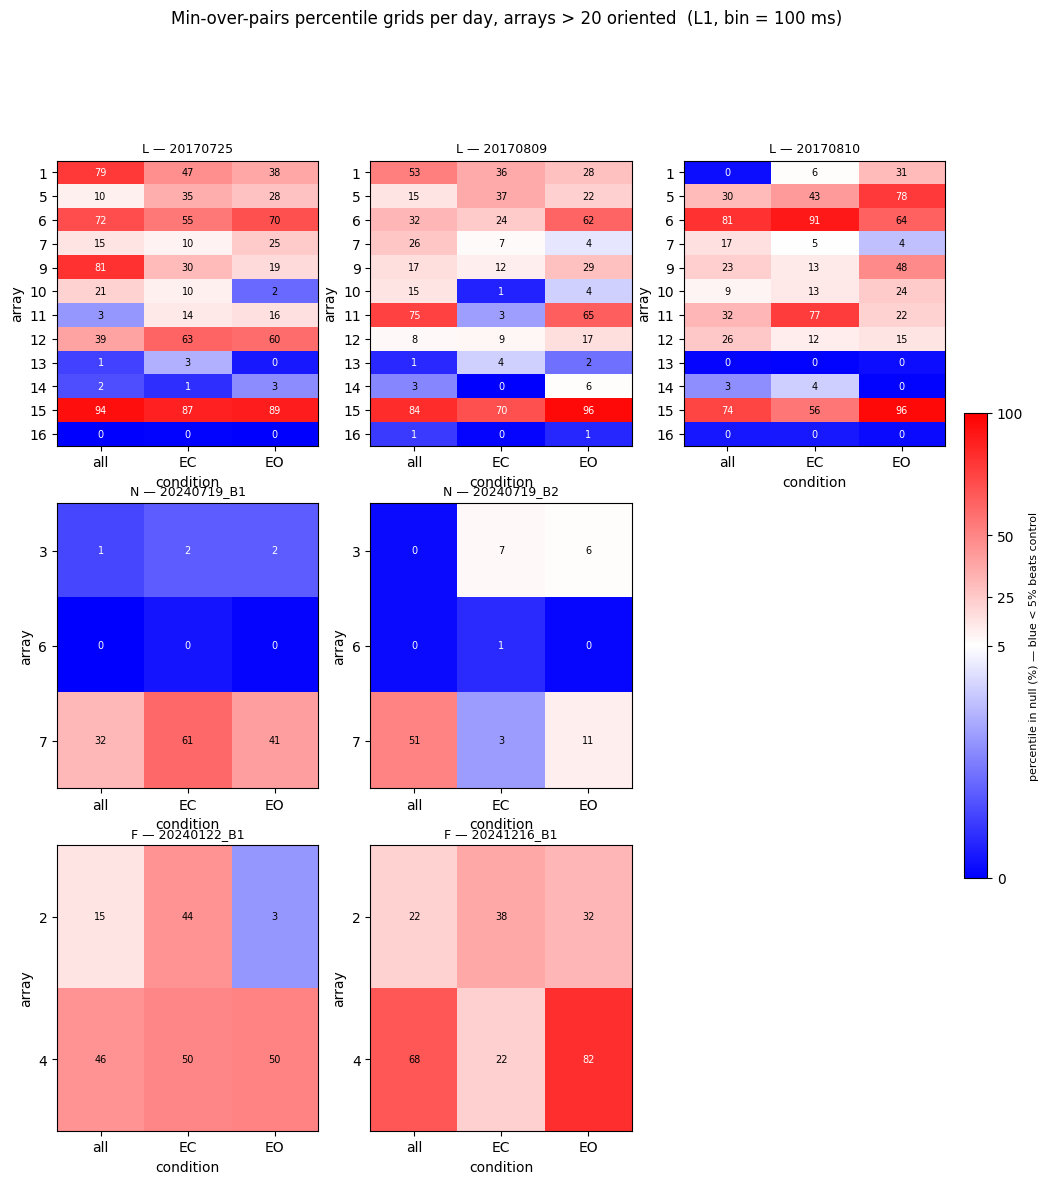

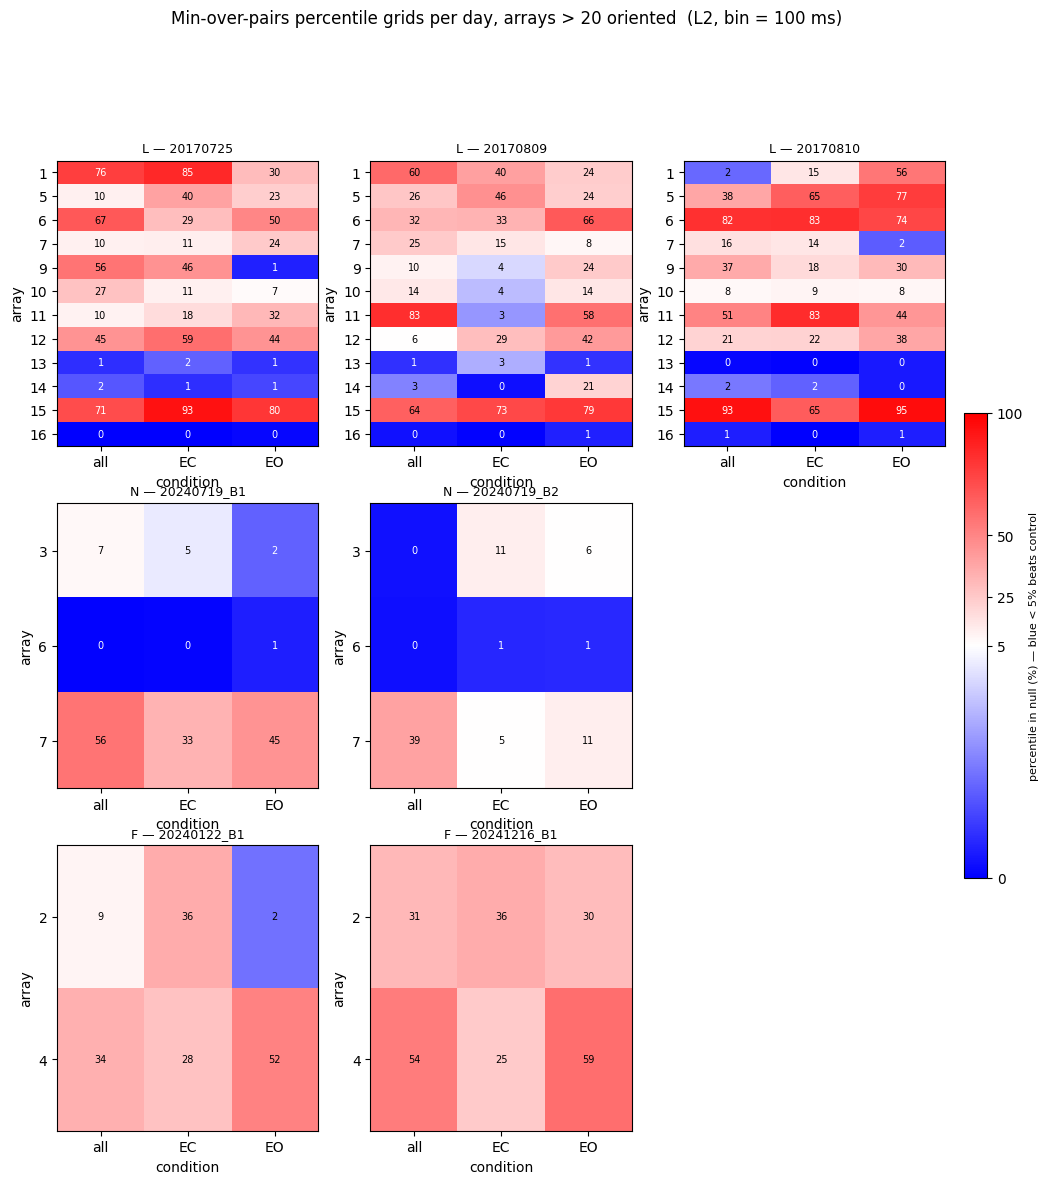

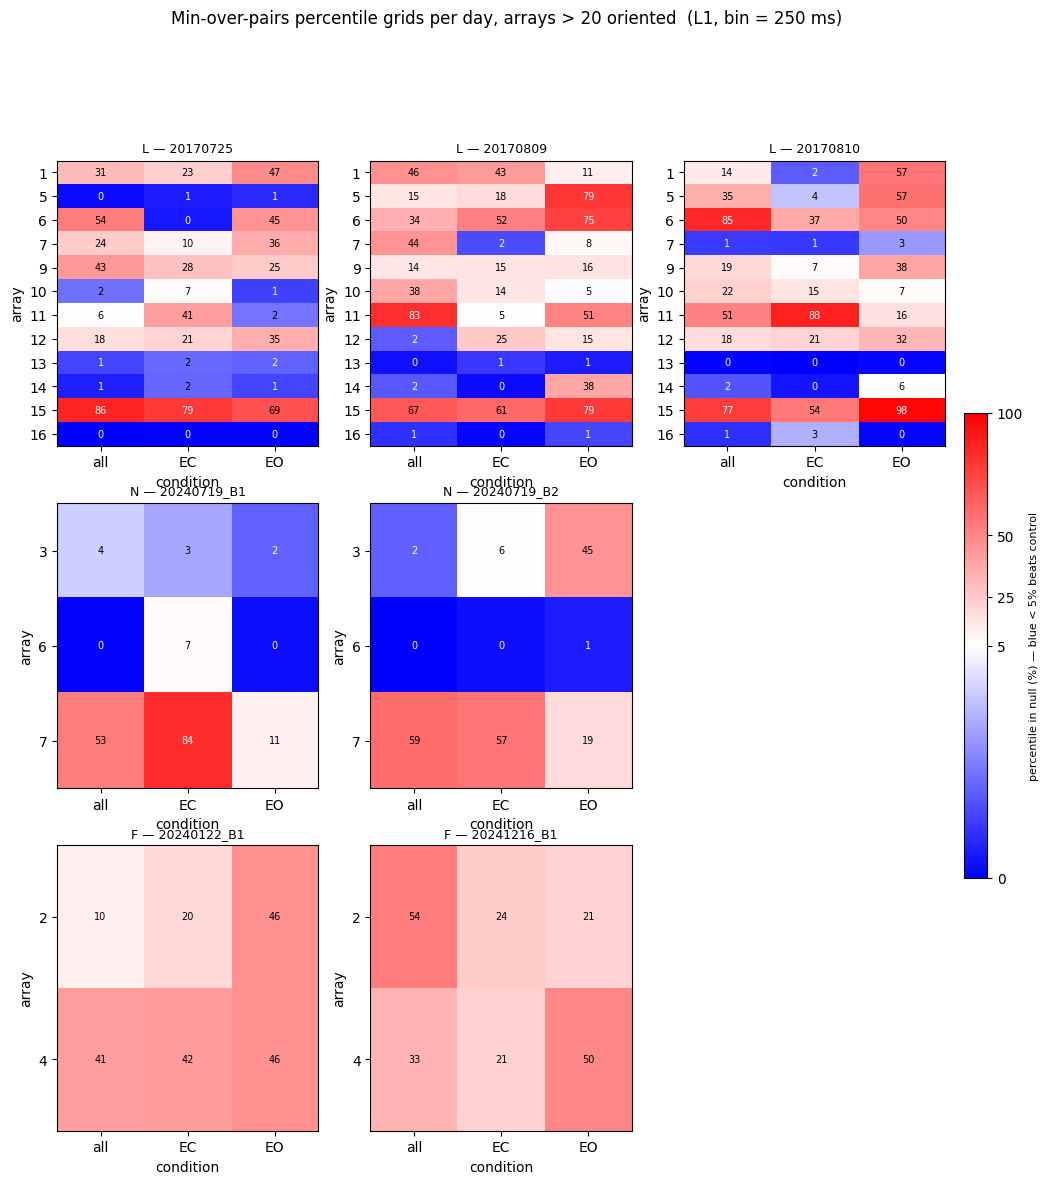

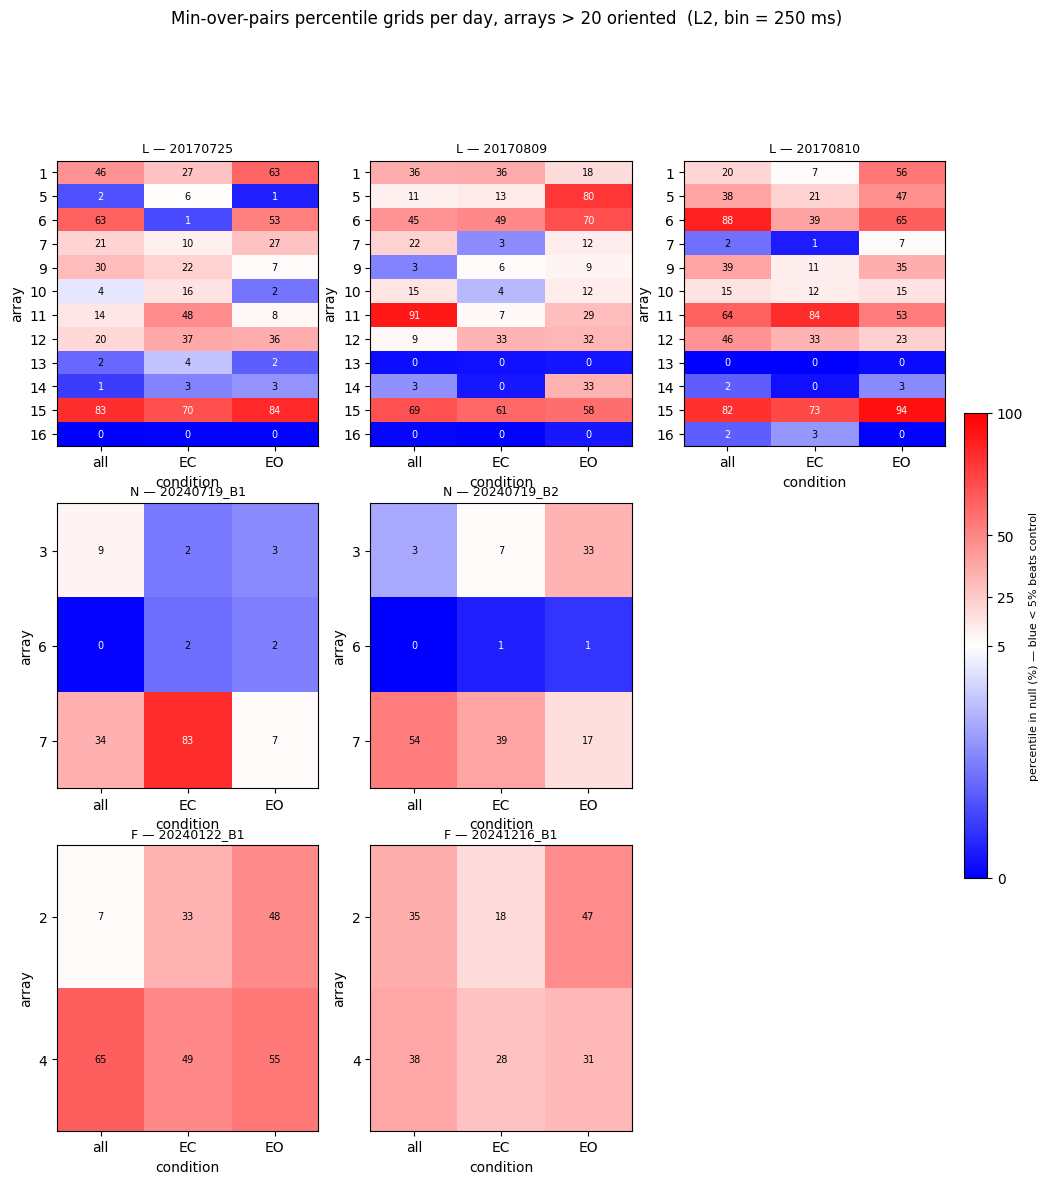

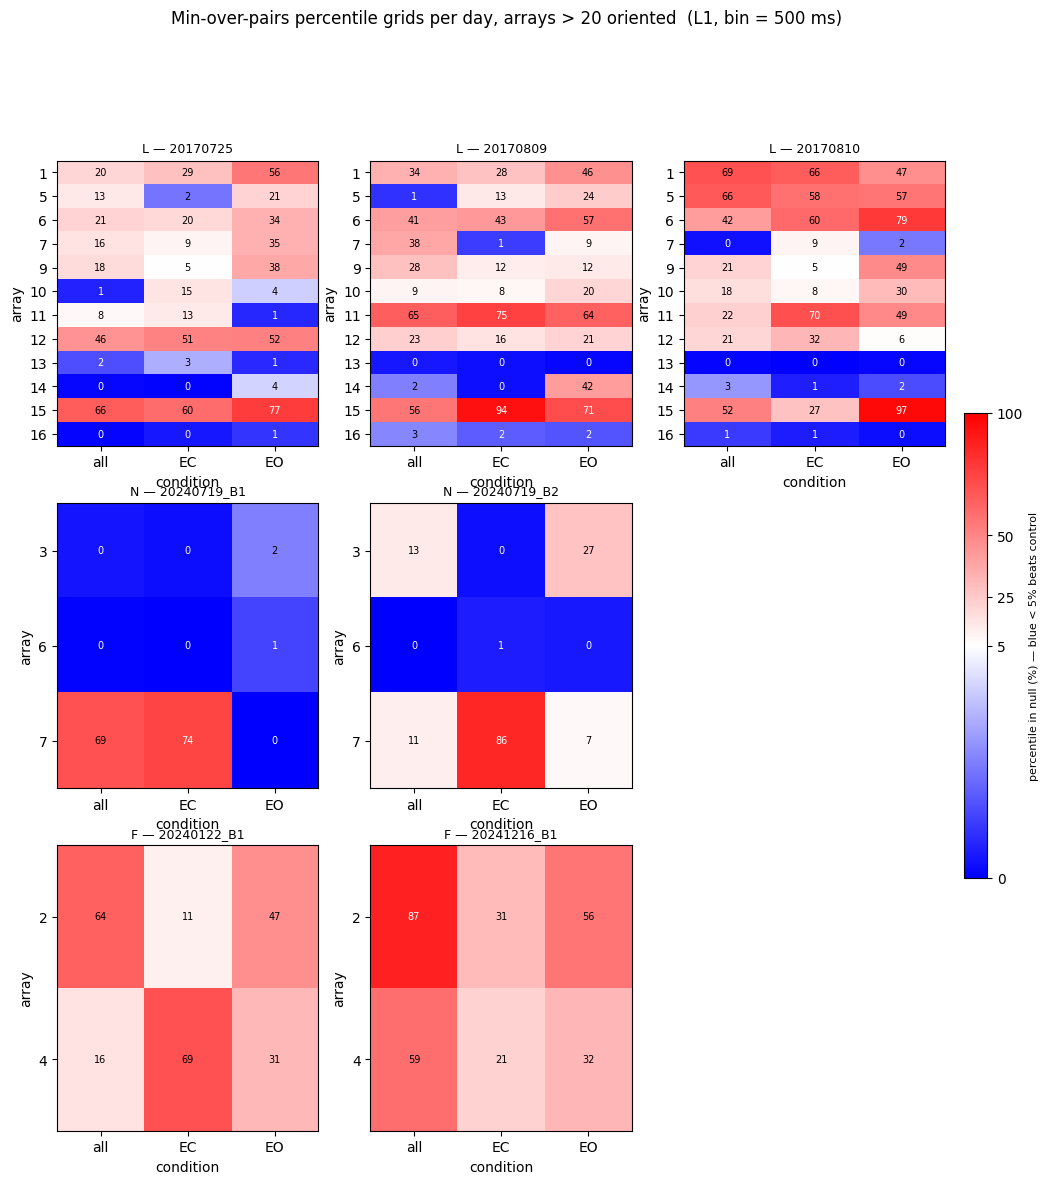

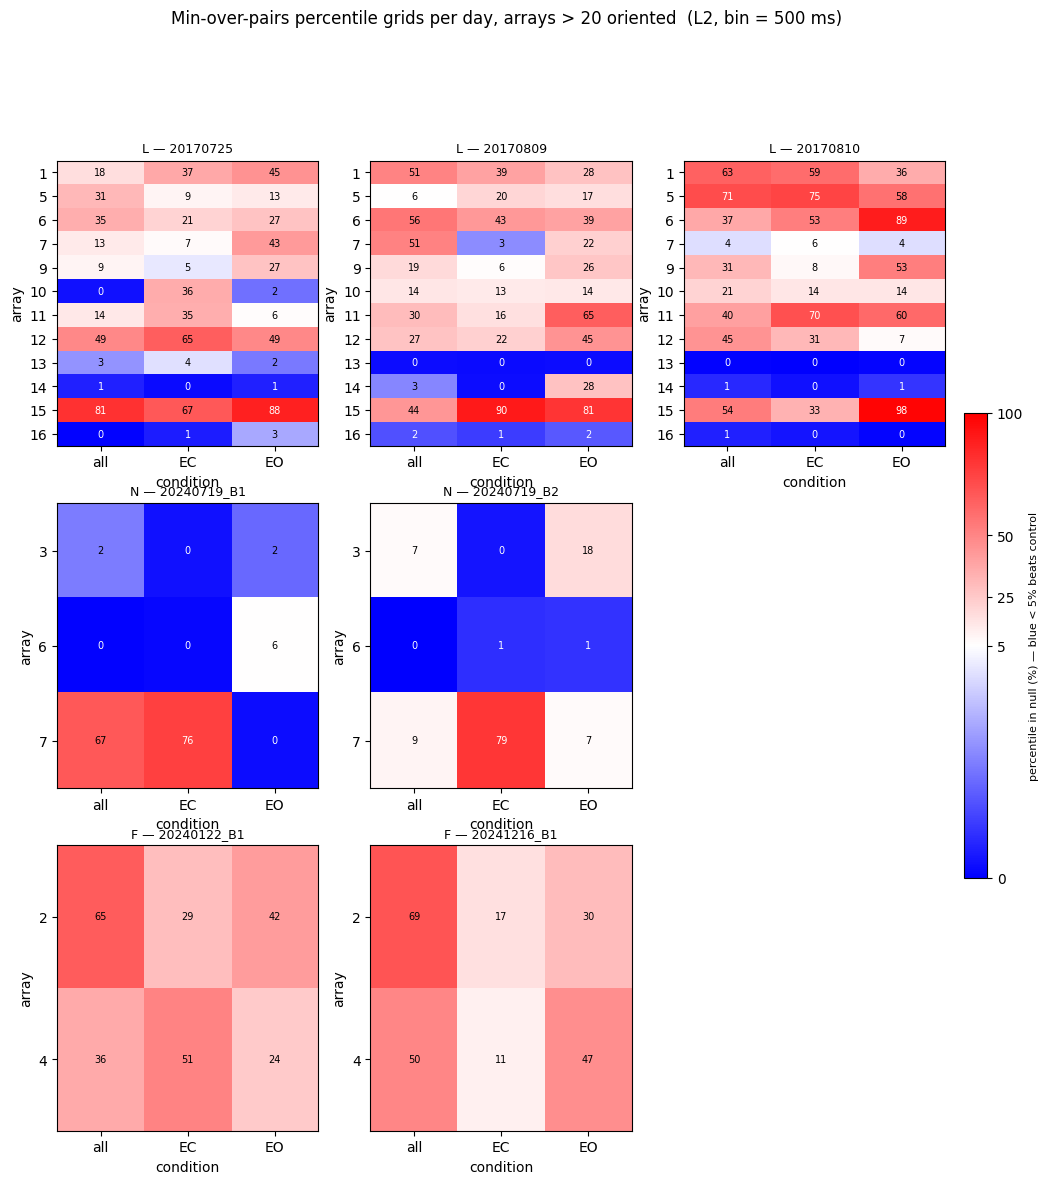

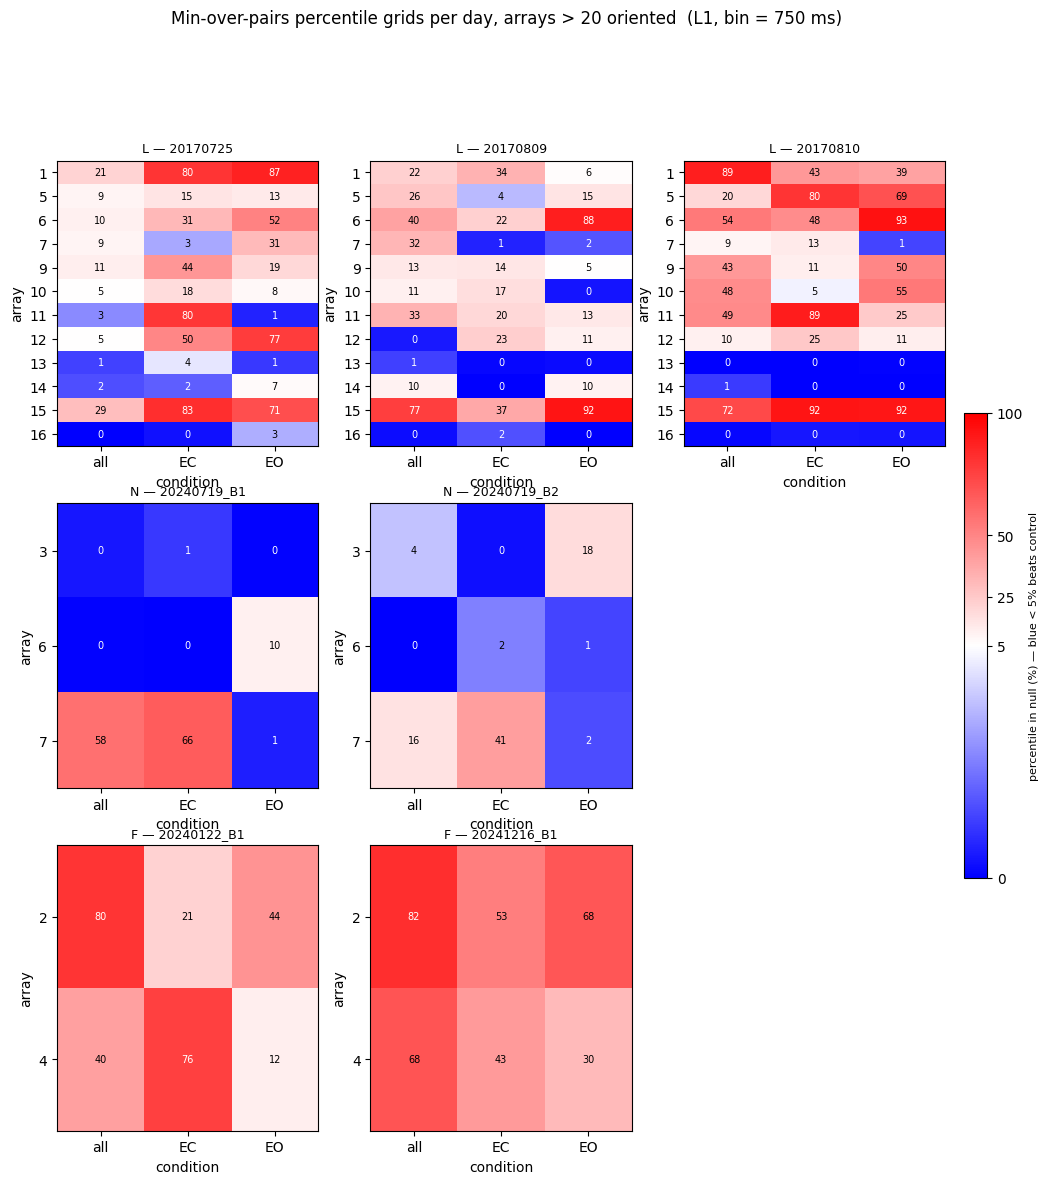

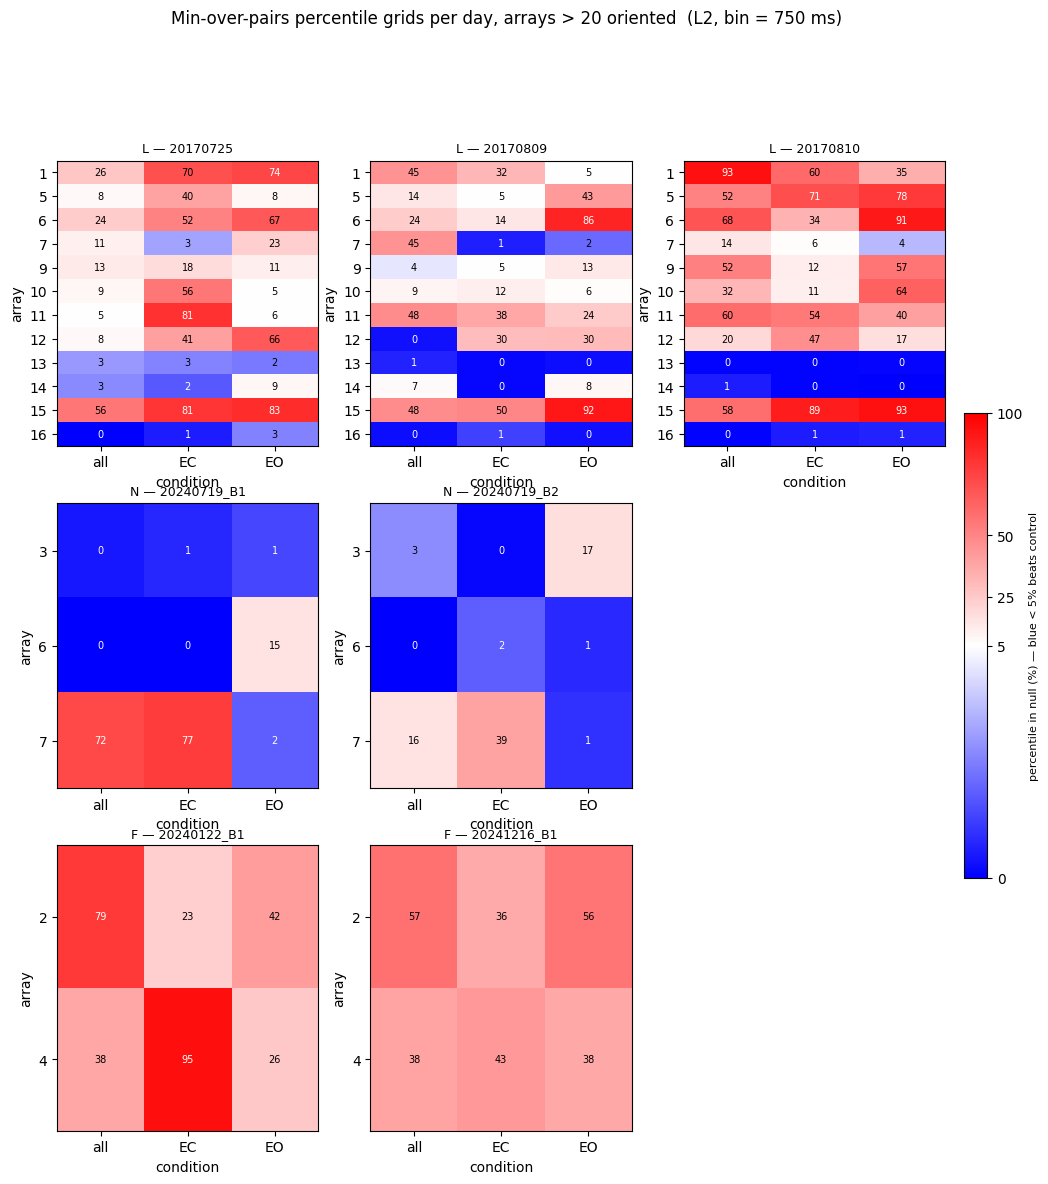

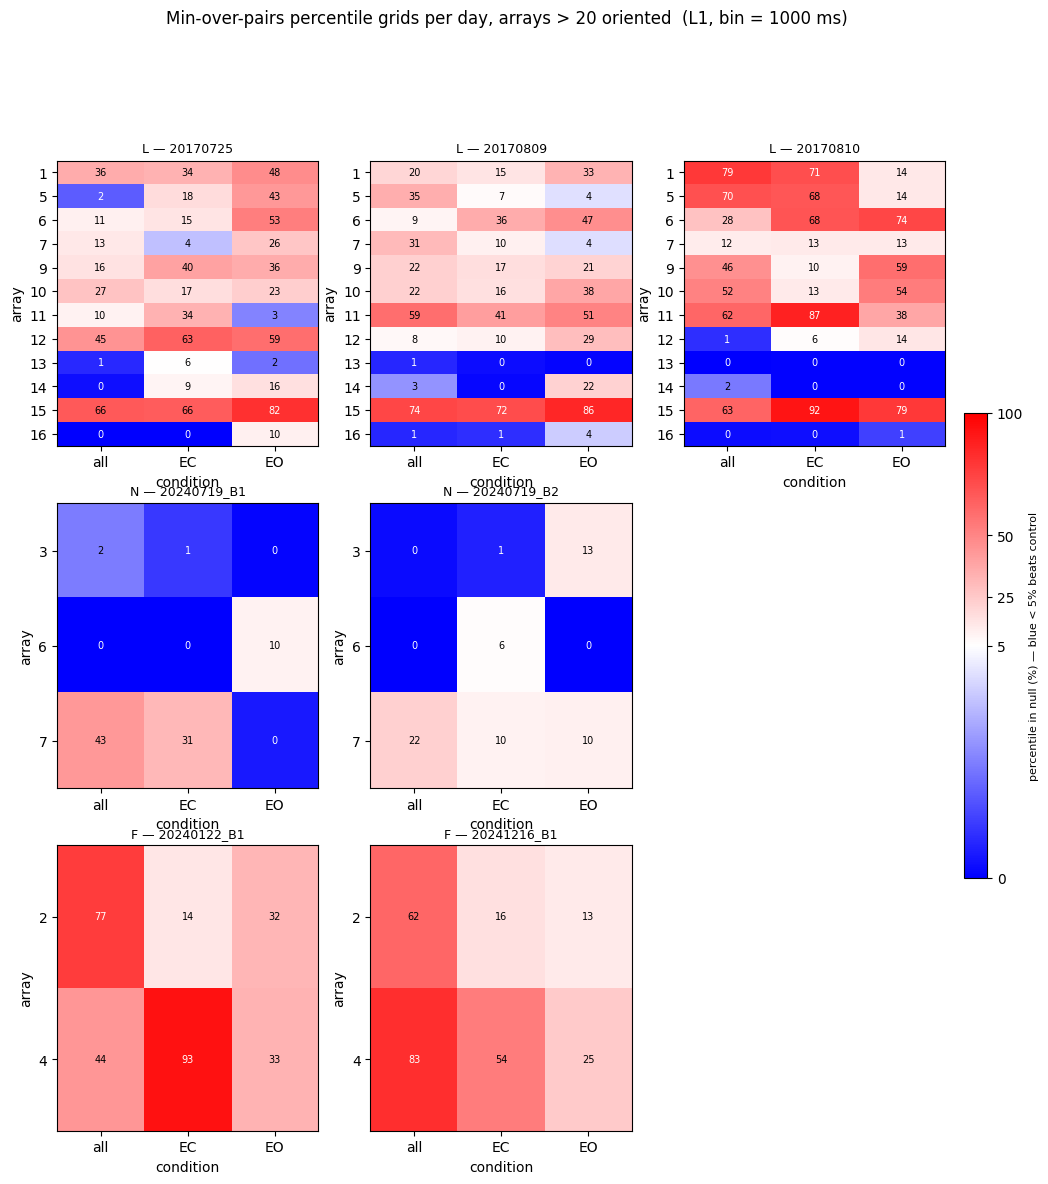

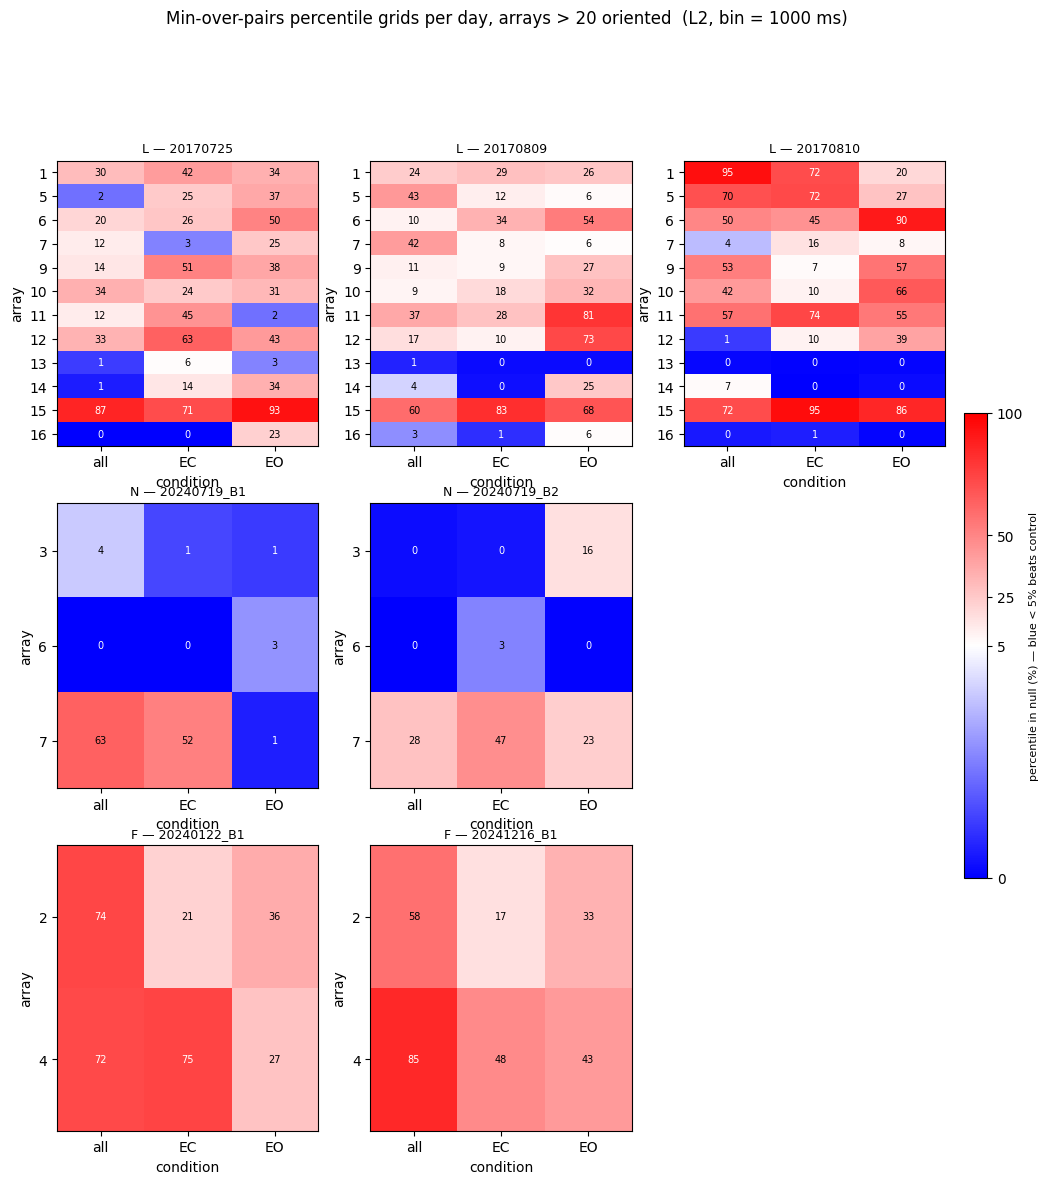

In [19]:
# oriented count per array (stable across days/conditions) — rebuild if needed
if "n_or_df" not in globals():
    with open(os.path.join(DF_FOLDER, "pca_scores_binsweep.pkl"), "rb") as f:
        pca_store = pickle.load(f)
    n_or_df = pd.DataFrame([
        dict(monkey=m, date=dt, array=int(a), condition=c, bin_ms=int(b),
             n_oriented=len(st["oriented_idx"]))
        for (m, dt, a, c, b), st in pca_store.items()]).drop_duplicates()

# arrays passing the > 20 oriented-channel threshold (per monkey)
MIN_ORIENTED = 20
per_array_count = n_or_df.groupby(["monkey","array"])["n_oriented"].max()
keep_arrays = {m: sorted(per_array_count.loc[m][per_array_count.loc[m] > MIN_ORIENTED].index)
               for m in MONKEYS}
print("arrays kept (> %d oriented):" % MIN_ORIENTED)
for m in MONKEYS:
    print(f"  {m}: {keep_arrays[m]}")


def grid_for_day_filt(mp, monkey, date, norm, arrays_keep):
    sub = mp[(mp.norm == norm) & (mp.monkey == monkey) & (mp.date == str(date))]
    conds = [c for c in ["all", "EC", "EO"] if c in sub["condition"].unique()]
    arrays = [a for a in sorted(sub["array"].unique()) if a in arrays_keep]
    grid = np.full((len(arrays), len(conds)), np.nan)
    for i, arr in enumerate(arrays):
        for j, cond in enumerate(conds):
            v = sub[(sub.array == arr) & (sub.condition == cond)]["percentile"]
            if len(v):
                grid[i, j] = v.iloc[0]
    return arrays, conds, grid

def draw_grid_day_filt(ax, mp, monkey, date, norm, arrays_keep):
    arrays, conds, grid = grid_for_day_filt(mp, monkey, date, norm, arrays_keep)
    cnorm = TwoSlopeNorm(vmin=0, vcenter=5, vmax=100)
    im = ax.imshow(grid, cmap="bwr", norm=cnorm, aspect="auto")
    ax.set_xticks(range(len(conds))); ax.set_xticklabels(conds)
    ax.set_yticks(range(len(arrays))); ax.set_yticklabels(arrays)
    ax.set_xlabel("condition"); ax.set_ylabel("array")
    ax.set_title(f"{monkey} — {date}", fontsize=9)
    for i in range(len(arrays)):
        for j in range(len(conds)):
            v = grid[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7,
                        color="white" if (v < 2 or v > 70) else "black")
    return im


monkey_dates = {m: DATES[m]["RS"] for m in MONKEYS}
max_cols = max(len(v) for v in monkey_dates.values())

for bin_plot in BIN_SIZES:
    mp_bin = minpair_percentile_df(df[df.bin_ms == bin_plot])
    for norm in ["L1", "L2"]:
        fig, axes = plt.subplots(len(MONKEYS), max_cols,
                                 figsize=(4.0*max_cols, 4.2*len(MONKEYS)),
                                 squeeze=False)
        im_last = None
        for r, monkey in enumerate(MONKEYS):
            dates = monkey_dates[monkey]
            for c in range(max_cols):
                ax = axes[r][c]
                if c < len(dates):
                    im_last = draw_grid_day_filt(ax, mp_bin, monkey, dates[c],
                                                 norm, keep_arrays[monkey])
                else:
                    ax.axis("off")
        cbar = fig.colorbar(im_last, ax=axes, fraction=0.025, pad=0.02,
                            ticks=[0, 5, 25, 50, 100])
        cbar.set_label("percentile in null (%) — blue < 5% beats control", fontsize=8)
        fig.suptitle(f"Min-over-pairs percentile grids per day, arrays > {MIN_ORIENTED} "
                     f"oriented  ({norm}, bin = {bin_plot} ms)", fontsize=12, y=1.0)
        plt.show()

arrays kept (> 24 oriented):
  L: [1, 7, 9, 10, 11, 12, 13, 14, 16]
  N: [3, 6]
  F: [4]


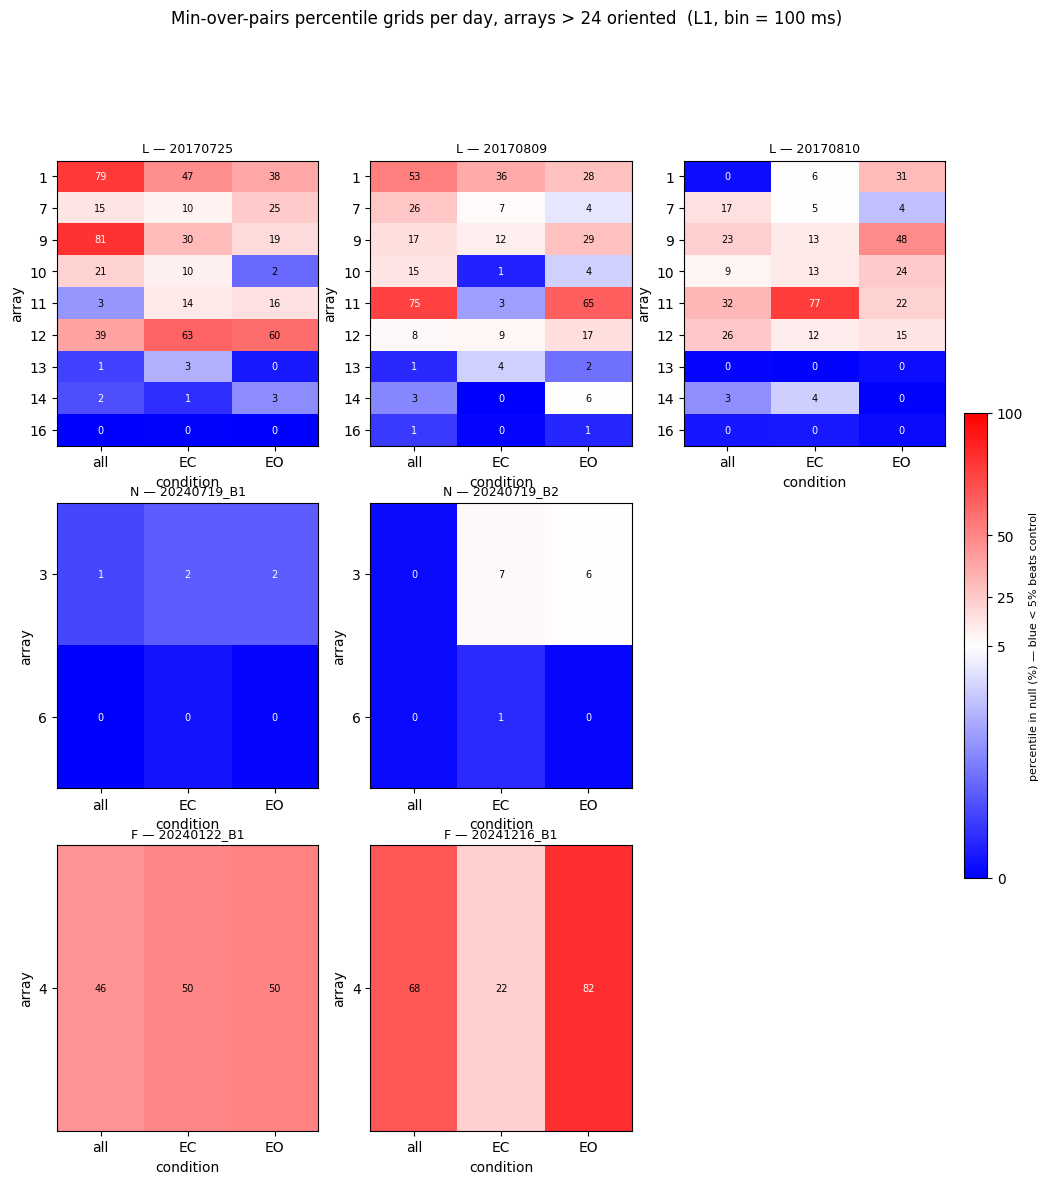

In [34]:
NORM = "L1"
BIN_PLOT = 100
MIN_ORIENTED = 24

# oriented count per array (rebuild if not in scope)
if "n_or_df" not in globals():
    with open(os.path.join(DF_FOLDER, "pca_scores_binsweep.pkl"), "rb") as f:
        pca_store = pickle.load(f)
    n_or_df = pd.DataFrame([
        dict(monkey=m, date=dt, array=int(a), condition=c, bin_ms=int(b),
             n_oriented=len(st["oriented_idx"]))
        for (m, dt, a, c, b), st in pca_store.items()]).drop_duplicates()

per_array_count = n_or_df.groupby(["monkey","array"])["n_oriented"].max()
keep_arrays = {m: sorted(per_array_count.loc[m][per_array_count.loc[m] > MIN_ORIENTED].index)
               for m in MONKEYS}
print(f"arrays kept (> {MIN_ORIENTED} oriented):")
for m in MONKEYS:
    print(f"  {m}: {keep_arrays[m]}")


def grid_for_day_filt(mp, monkey, date, norm, arrays_keep):
    sub = mp[(mp.norm == norm) & (mp.monkey == monkey) & (mp.date == str(date))]
    conds = [c for c in ["all", "EC", "EO"] if c in sub["condition"].unique()]
    arrays = [a for a in sorted(sub["array"].unique()) if a in arrays_keep]
    grid = np.full((len(arrays), len(conds)), np.nan)
    for i, arr in enumerate(arrays):
        for j, cond in enumerate(conds):
            v = sub[(sub.array == arr) & (sub.condition == cond)]["percentile"]
            if len(v):
                grid[i, j] = v.iloc[0]
    return arrays, conds, grid

def draw_grid_day_filt(ax, mp, monkey, date, norm, arrays_keep):
    arrays, conds, grid = grid_for_day_filt(mp, monkey, date, norm, arrays_keep)
    cnorm = TwoSlopeNorm(vmin=0, vcenter=5, vmax=100)
    im = ax.imshow(grid, cmap="bwr", norm=cnorm, aspect="auto")
    ax.set_xticks(range(len(conds))); ax.set_xticklabels(conds)
    ax.set_yticks(range(len(arrays))); ax.set_yticklabels(arrays)
    ax.set_xlabel("condition"); ax.set_ylabel("array")
    ax.set_title(f"{monkey} — {date}", fontsize=9)
    for i in range(len(arrays)):
        for j in range(len(conds)):
            v = grid[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7,
                        color="white" if (v < 2 or v > 70) else "black")
    return im


mp_bin = minpair_percentile_df(df[df.bin_ms == BIN_PLOT])
monkey_dates = {m: DATES[m]["RS"] for m in MONKEYS}
max_cols = max(len(v) for v in monkey_dates.values())

fig, axes = plt.subplots(len(MONKEYS), max_cols,
                         figsize=(4.0*max_cols, 4.2*len(MONKEYS)),
                         squeeze=False)
im_last = None
for r, monkey in enumerate(MONKEYS):
    dates = monkey_dates[monkey]
    for c in range(max_cols):
        ax = axes[r][c]
        if c < len(dates):
            im_last = draw_grid_day_filt(ax, mp_bin, monkey, dates[c],
                                         NORM, keep_arrays[monkey])
        else:
            ax.axis("off")
cbar = fig.colorbar(im_last, ax=axes, fraction=0.025, pad=0.02,
                    ticks=[0, 5, 25, 50, 100])
cbar.set_label("percentile in null (%) — blue < 5% beats control", fontsize=8)
fig.suptitle(f"Min-over-pairs percentile grids per day, arrays > {MIN_ORIENTED} "
             f"oriented  ({NORM}, bin = {BIN_PLOT} ms)", fontsize=12, y=1.0)
plt.show()

arrays kept (> 24 oriented):
  L: [1, 7, 9, 10, 11, 12, 13, 14, 16]
  N: [3, 6]
  F: [4]


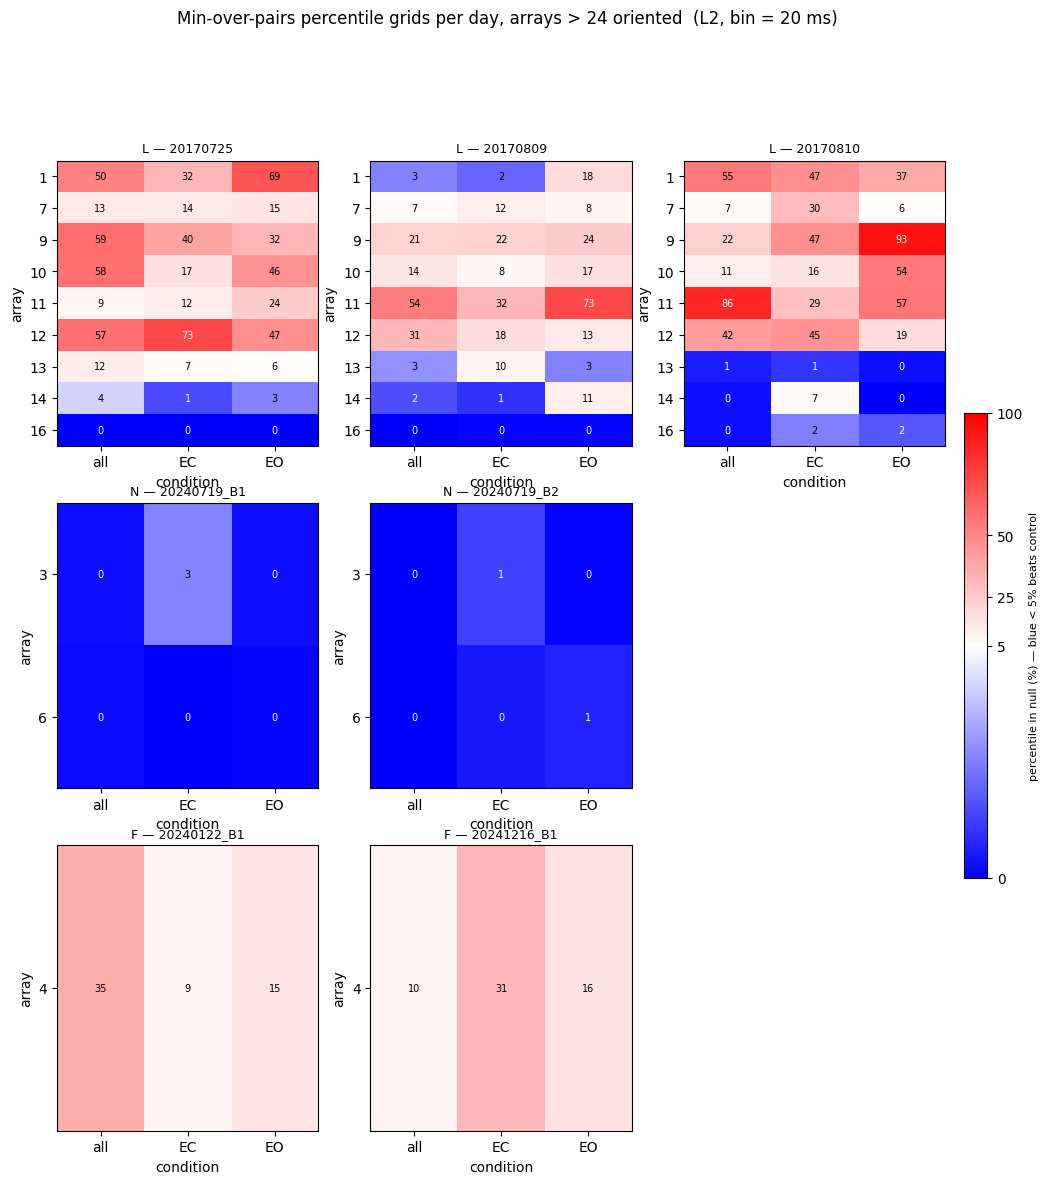

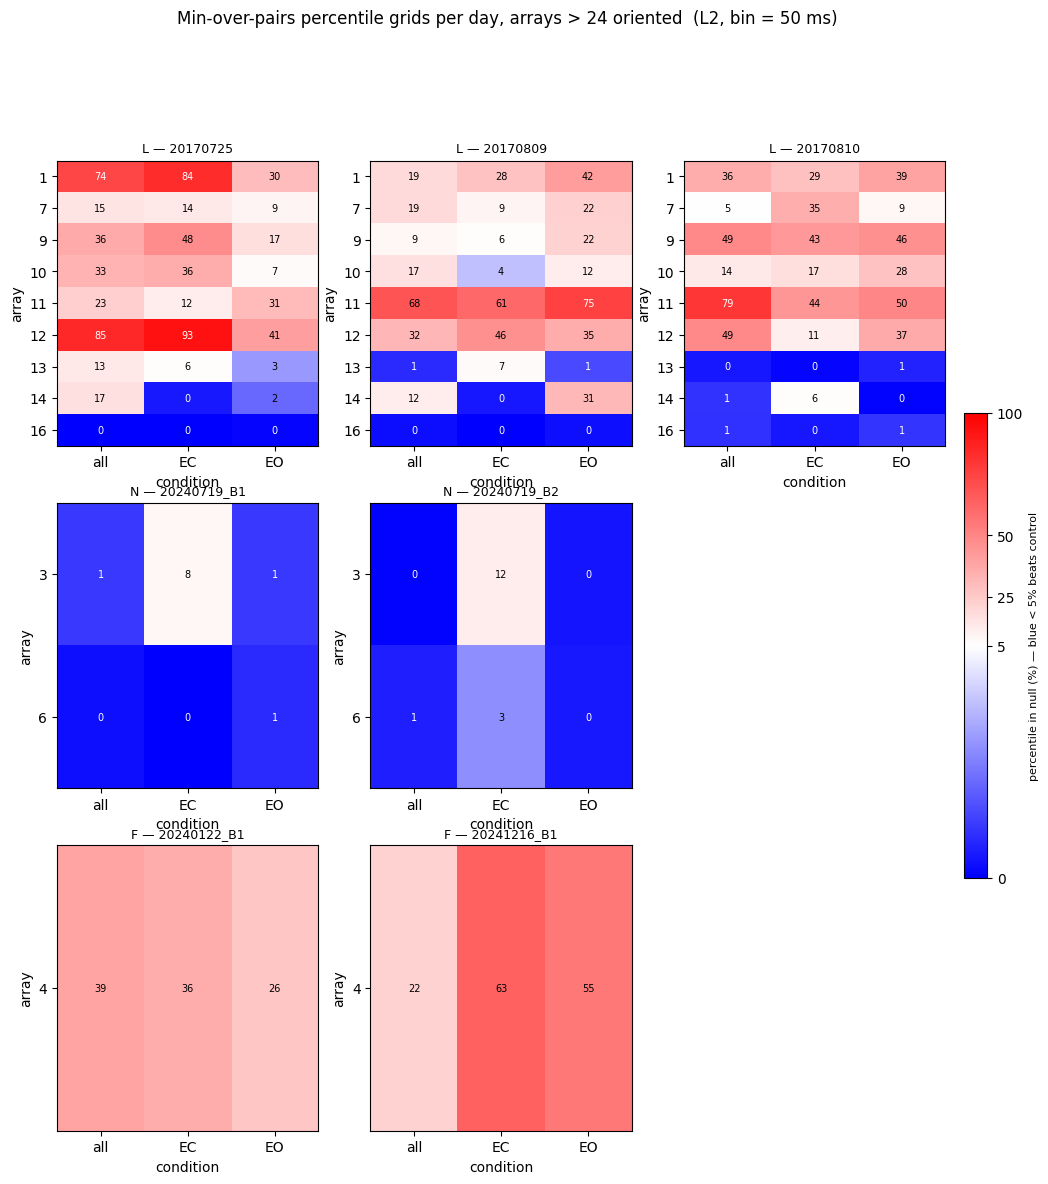

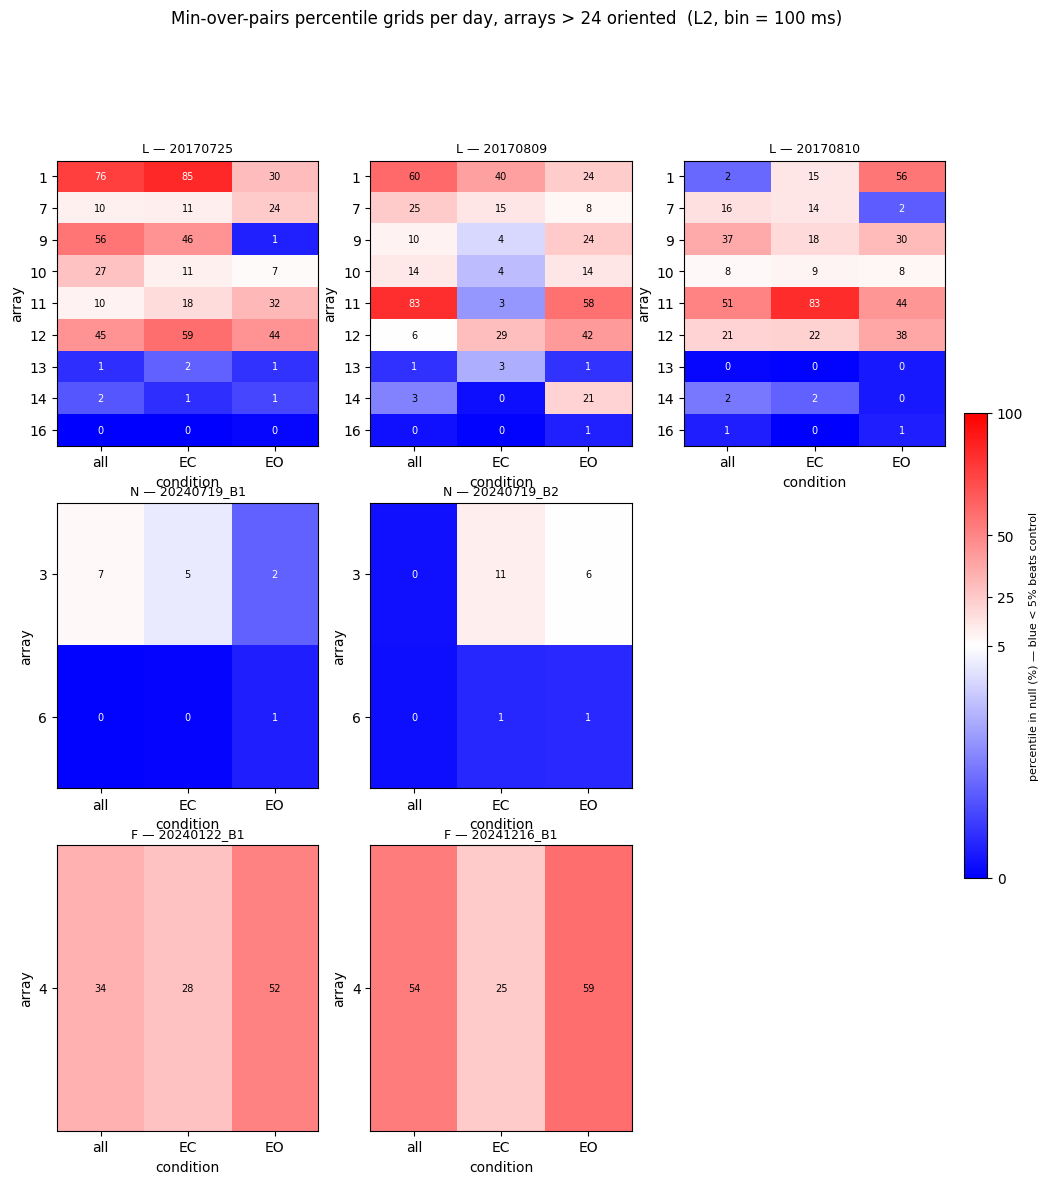

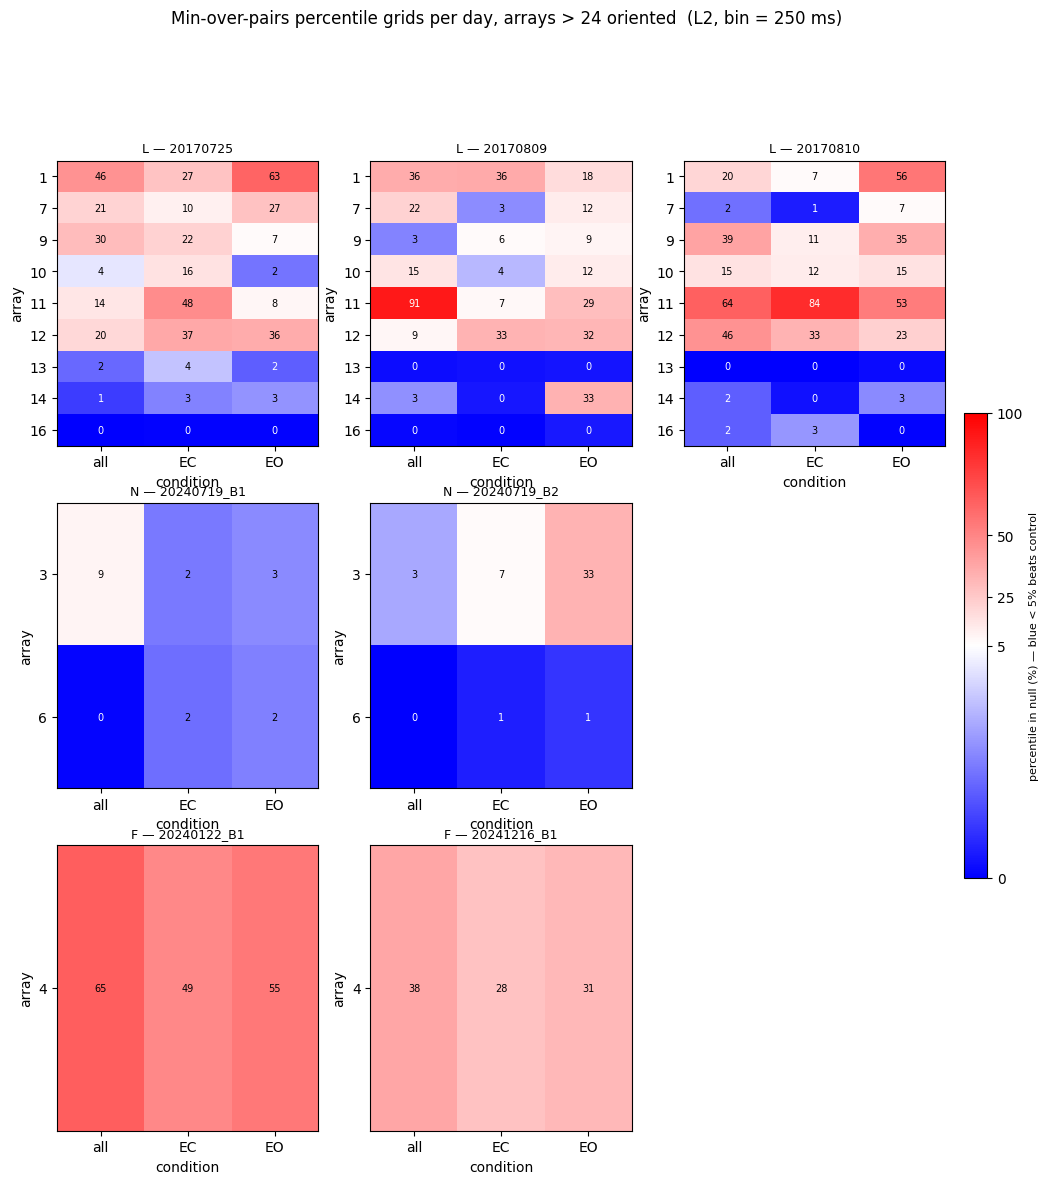

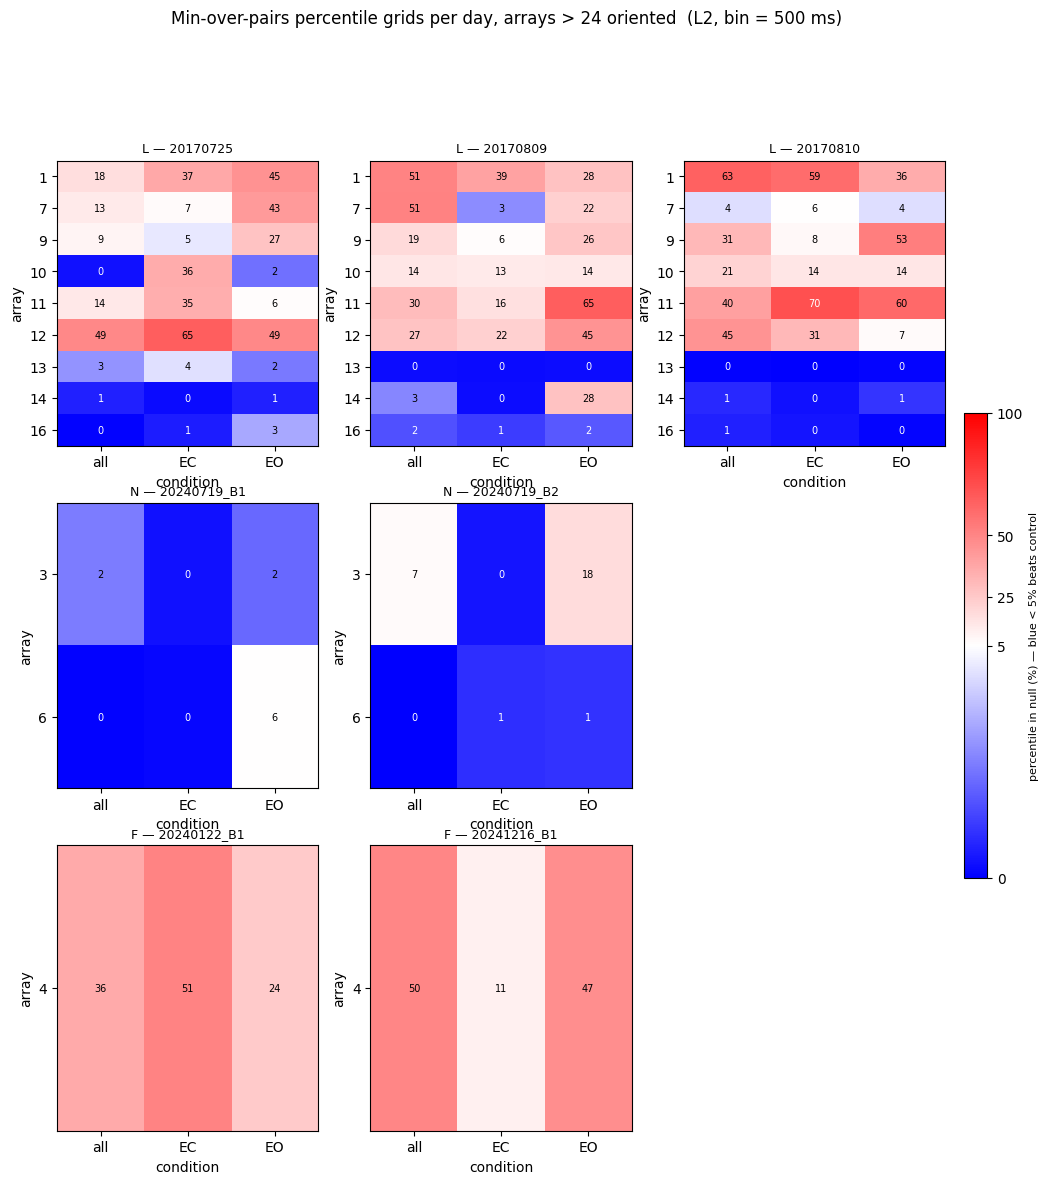

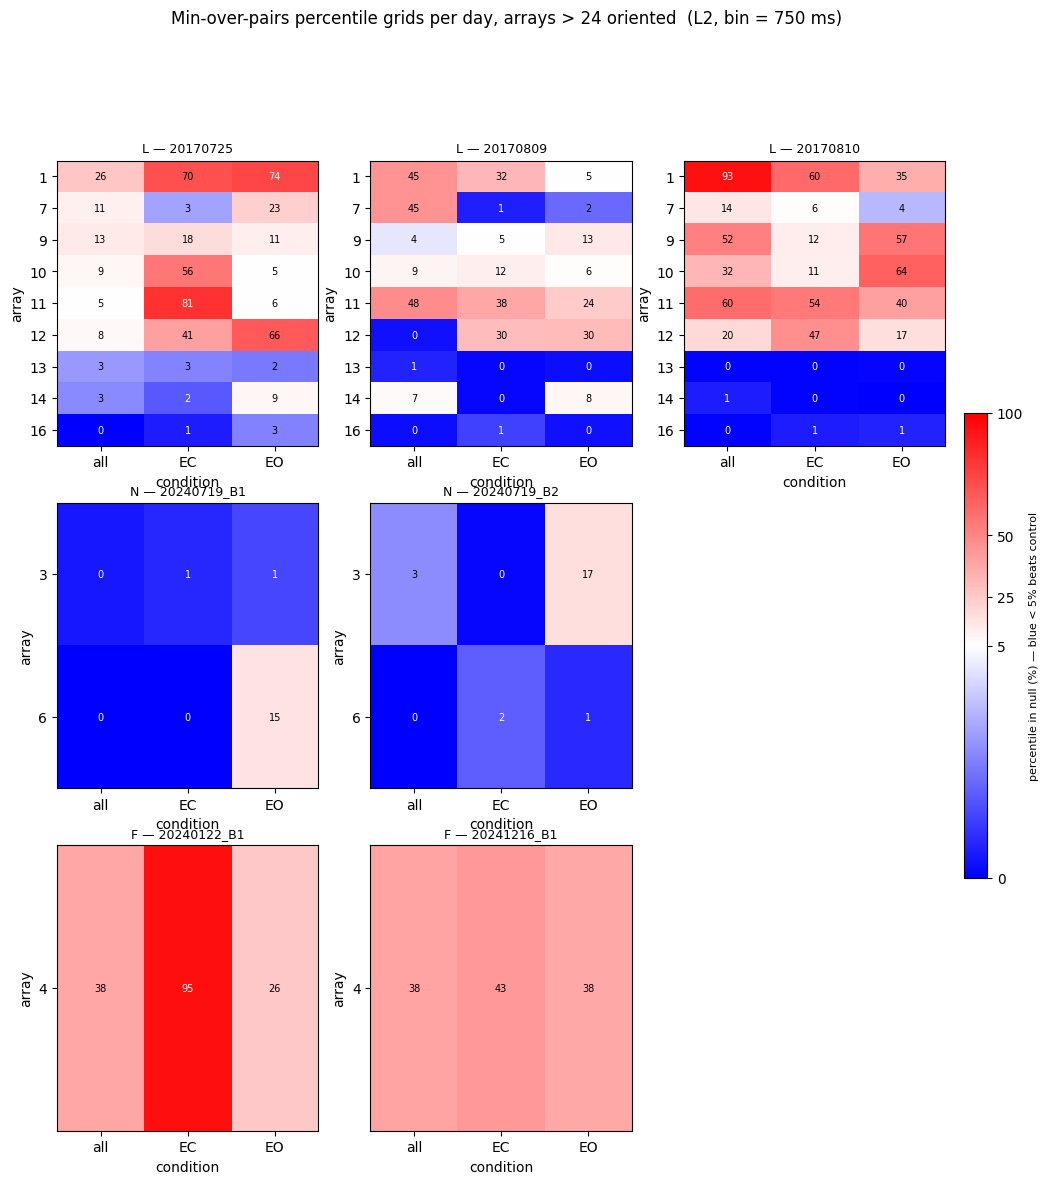

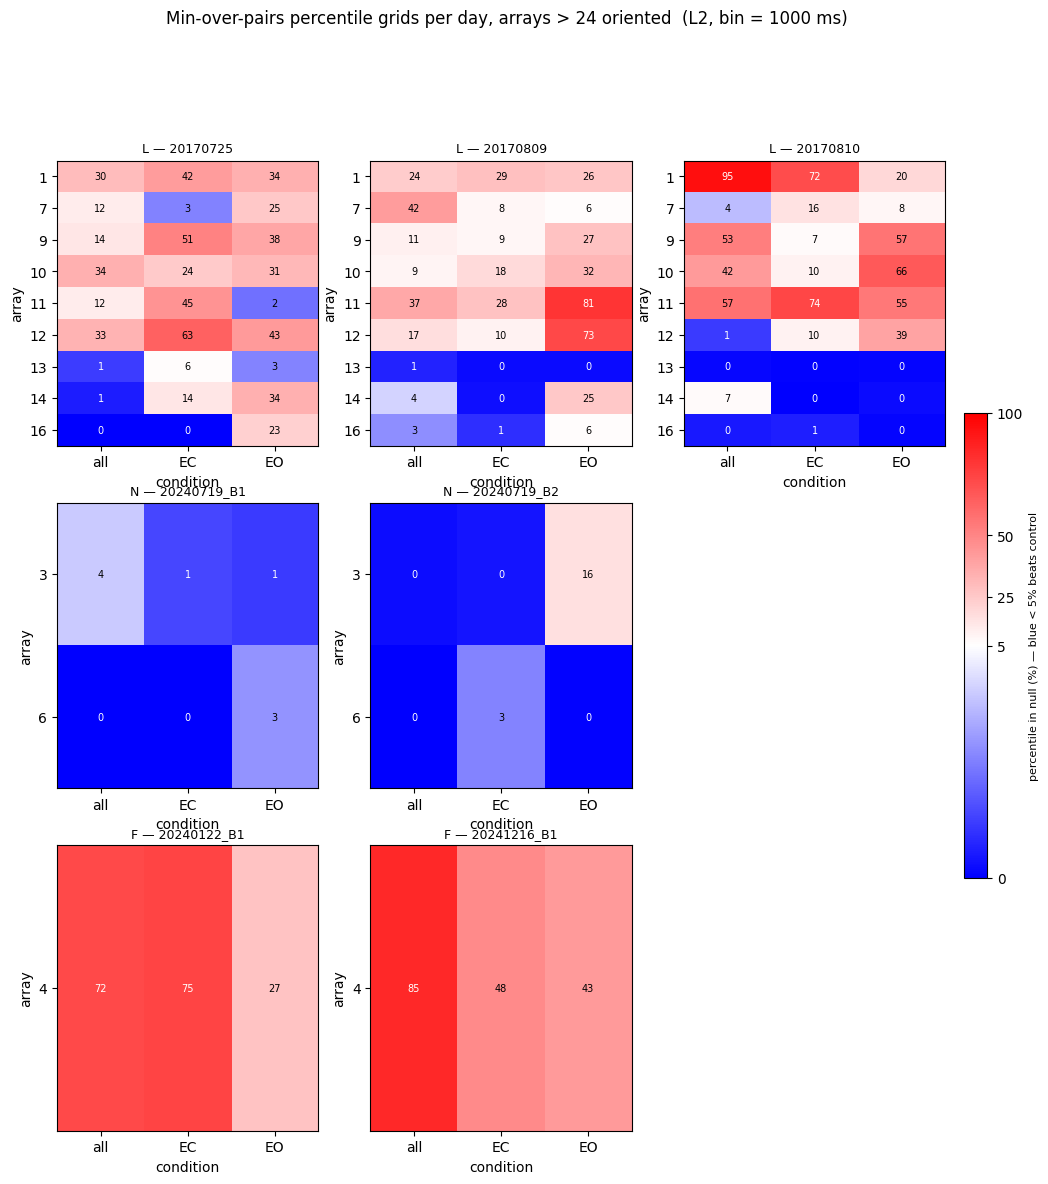

In [30]:
NORM = "L2"
MIN_ORIENTED = 24

# oriented count per array (rebuild if not in scope)
if "n_or_df" not in globals():
    with open(os.path.join(DF_FOLDER, "pca_scores_binsweep.pkl"), "rb") as f:
        pca_store = pickle.load(f)
    n_or_df = pd.DataFrame([
        dict(monkey=m, date=dt, array=int(a), condition=c, bin_ms=int(b),
             n_oriented=len(st["oriented_idx"]))
        for (m, dt, a, c, b), st in pca_store.items()]).drop_duplicates()

per_array_count = n_or_df.groupby(["monkey","array"])["n_oriented"].max()
keep_arrays = {m: sorted(per_array_count.loc[m][per_array_count.loc[m] > MIN_ORIENTED].index)
               for m in MONKEYS}
print(f"arrays kept (> {MIN_ORIENTED} oriented):")
for m in MONKEYS:
    print(f"  {m}: {keep_arrays[m]}")


def grid_for_day_filt(mp, monkey, date, norm, arrays_keep):
    sub = mp[(mp.norm == norm) & (mp.monkey == monkey) & (mp.date == str(date))]
    conds = [c for c in ["all", "EC", "EO"] if c in sub["condition"].unique()]
    arrays = [a for a in sorted(sub["array"].unique()) if a in arrays_keep]
    grid = np.full((len(arrays), len(conds)), np.nan)
    for i, arr in enumerate(arrays):
        for j, cond in enumerate(conds):
            v = sub[(sub.array == arr) & (sub.condition == cond)]["percentile"]
            if len(v):
                grid[i, j] = v.iloc[0]
    return arrays, conds, grid

def draw_grid_day_filt(ax, mp, monkey, date, norm, arrays_keep):
    arrays, conds, grid = grid_for_day_filt(mp, monkey, date, norm, arrays_keep)
    cnorm = TwoSlopeNorm(vmin=0, vcenter=5, vmax=100)
    im = ax.imshow(grid, cmap="bwr", norm=cnorm, aspect="auto")
    ax.set_xticks(range(len(conds))); ax.set_xticklabels(conds)
    ax.set_yticks(range(len(arrays))); ax.set_yticklabels(arrays)
    ax.set_xlabel("condition"); ax.set_ylabel("array")
    ax.set_title(f"{monkey} — {date}", fontsize=9)
    for i in range(len(arrays)):
        for j in range(len(conds)):
            v = grid[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7,
                        color="white" if (v < 2 or v > 70) else "black")
    return im


monkey_dates = {m: DATES[m]["RS"] for m in MONKEYS}
max_cols = max(len(v) for v in monkey_dates.values())

for BIN_PLOT in BIN_SIZES:
    mp_bin = minpair_percentile_df(df[df.bin_ms == BIN_PLOT])
    fig, axes = plt.subplots(len(MONKEYS), max_cols,
                             figsize=(4.0*max_cols, 4.2*len(MONKEYS)),
                             squeeze=False)
    im_last = None
    for r, monkey in enumerate(MONKEYS):
        dates = monkey_dates[monkey]
        for c in range(max_cols):
            ax = axes[r][c]
            if c < len(dates):
                im_last = draw_grid_day_filt(ax, mp_bin, monkey, dates[c],
                                             NORM, keep_arrays[monkey])
            else:
                ax.axis("off")
    cbar = fig.colorbar(im_last, ax=axes, fraction=0.025, pad=0.02,
                        ticks=[0, 5, 25, 50, 100])
    cbar.set_label("percentile in null (%) — blue < 5% beats control", fontsize=8)
    fig.suptitle(f"Min-over-pairs percentile grids per day, arrays > {MIN_ORIENTED} "
                 f"oriented  ({NORM}, bin = {BIN_PLOT} ms)", fontsize=12, y=1.0)
    plt.show()

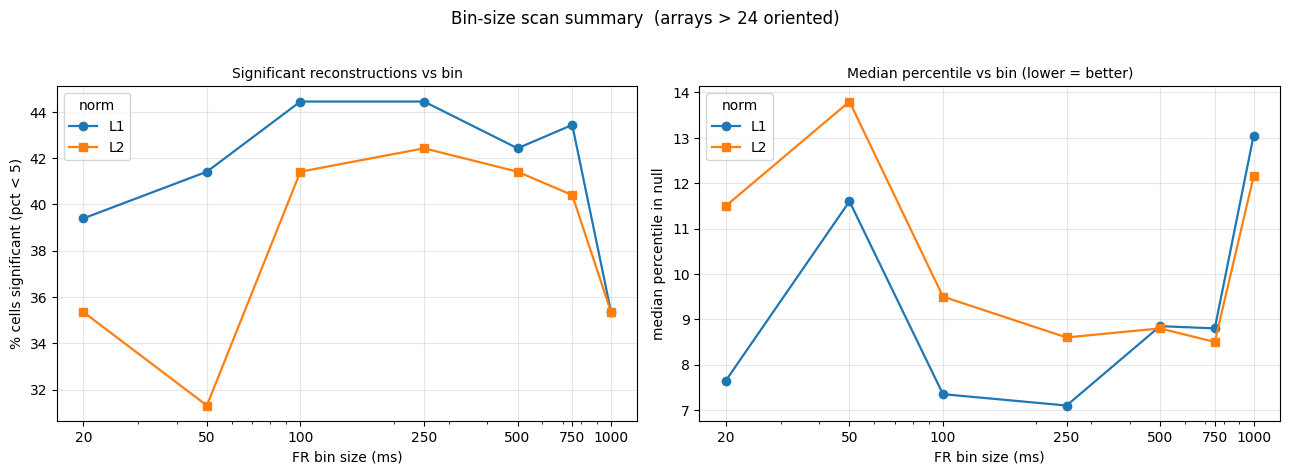

L1: most significant -> 100 ms (44% sig);  lowest median pct -> 250 ms (7.1)
L2: most significant -> 250 ms (42% sig);  lowest median pct -> 750 ms (8.5)


,bin_ms,norm,frac_sig,median_pct,mean_pct,n
0,20,L1,0.393939,7.65,16.916162,99
1,20,L2,0.353535,11.50,19.622222,99
2,50,L1,0.414141,11.60,20.185354,99
3,50,L2,0.313131,13.80,22.269697,99
4,100,L1,0.444444,7.35,17.525758,99
5,100,L2,0.414141,9.50,18.760606,99
6,250,L1,0.444444,7.10,16.377778,99
7,250,L2,0.424242,8.60,17.478788,99
8,500,L1,0.424242,8.85,18.114646,99
9,500,L2,0.414141,8.80,18.468182,99


In [33]:
MIN_ORIENTED = 24
SIG_THRESH = 5.0

# arrays passing the threshold (rebuild n_or_df if not in scope)
if "n_or_df" not in globals():
    with open(os.path.join(DF_FOLDER, "pca_scores_binsweep.pkl"), "rb") as f:
        pca_store = pickle.load(f)
    n_or_df = pd.DataFrame([
        dict(monkey=m, date=dt, array=int(a), condition=c, bin_ms=int(b),
             n_oriented=len(st["oriented_idx"]))
        for (m, dt, a, c, b), st in pca_store.items()]).drop_duplicates()
per_array_count = n_or_df.groupby(["monkey","array"])["n_oriented"].max()
keep_pairs = {(m, a) for (m, a) in per_array_count.index
              if per_array_count.loc[(m, a)] > MIN_ORIENTED}

# summarise each bin
recs = []
for bm in BIN_SIZES:
    mp_bin = minpair_percentile_df(df[df.bin_ms == bm])
    keep_mask = pd.MultiIndex.from_arrays(
        [mp_bin["monkey"], mp_bin["array"]]).isin(keep_pairs)
    mp_bin = mp_bin[keep_mask]
    for norm in ["L1", "L2"]:
        s = mp_bin[mp_bin.norm == norm]["percentile"].dropna()
        if len(s):
            recs.append(dict(bin_ms=bm, norm=norm,
                             frac_sig=float(np.mean(s < SIG_THRESH)),
                             median_pct=float(np.median(s)),
                             mean_pct=float(np.mean(s)), n=len(s)))
summary = pd.DataFrame(recs)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

# left: fraction significant (higher = better)
for norm, mark in [("L1","o"), ("L2","s")]:
    s = summary[summary.norm == norm]
    axes[0].plot(s["bin_ms"], 100*s["frac_sig"], marker=mark, lw=1.6, label=norm)
axes[0].set_xscale("log"); axes[0].set_xticks(BIN_SIZES); axes[0].set_xticklabels(BIN_SIZES)
axes[0].set_xlabel("FR bin size (ms)")
axes[0].set_ylabel(f"% cells significant (pct < {SIG_THRESH:.0f})")
axes[0].set_title("Significant reconstructions vs bin", fontsize=10)
axes[0].legend(title="norm"); axes[0].grid(alpha=0.3)

# right: median percentile (lower = better)
for norm, mark in [("L1","o"), ("L2","s")]:
    s = summary[summary.norm == norm]
    axes[1].plot(s["bin_ms"], s["median_pct"], marker=mark, lw=1.6, label=norm)
axes[1].set_xscale("log"); axes[1].set_xticks(BIN_SIZES); axes[1].set_xticklabels(BIN_SIZES)
axes[1].set_xlabel("FR bin size (ms)")
axes[1].set_ylabel("median percentile in null")
axes[1].set_title("Median percentile vs bin (lower = better)", fontsize=10)
axes[1].legend(title="norm"); axes[1].grid(alpha=0.3)

fig.suptitle(f"Bin-size scan summary  (arrays > {MIN_ORIENTED} oriented)",
             fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

# mark the winners
for norm in ["L1", "L2"]:
    s = summary[summary.norm == norm]
    best_sig = s.loc[s["frac_sig"].idxmax()]
    best_med = s.loc[s["median_pct"].idxmin()]
    print(f"{norm}: most significant -> {int(best_sig.bin_ms)} ms "
          f"({100*best_sig.frac_sig:.0f}% sig);  "
          f"lowest median pct -> {int(best_med.bin_ms)} ms "
          f"({best_med.median_pct:.1f})")
summary